<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `nSTATPaperExamples.mlx`
- Fidelity status: `exact`
- Remaining justified differences: Workflow, API surface, dataset loading, and all 30 figures now follow the MATLAB paper-example helpfile. Only inherent Python GLM/decoder numerics and matplotlib styling differ.


{'dataset_root': '/Users/iahncajigas/Library/CloudStorage/Dropbox/Claude/nSTAT-python/data_cache/nstat_data', 'paper_examples_loaded': 8}


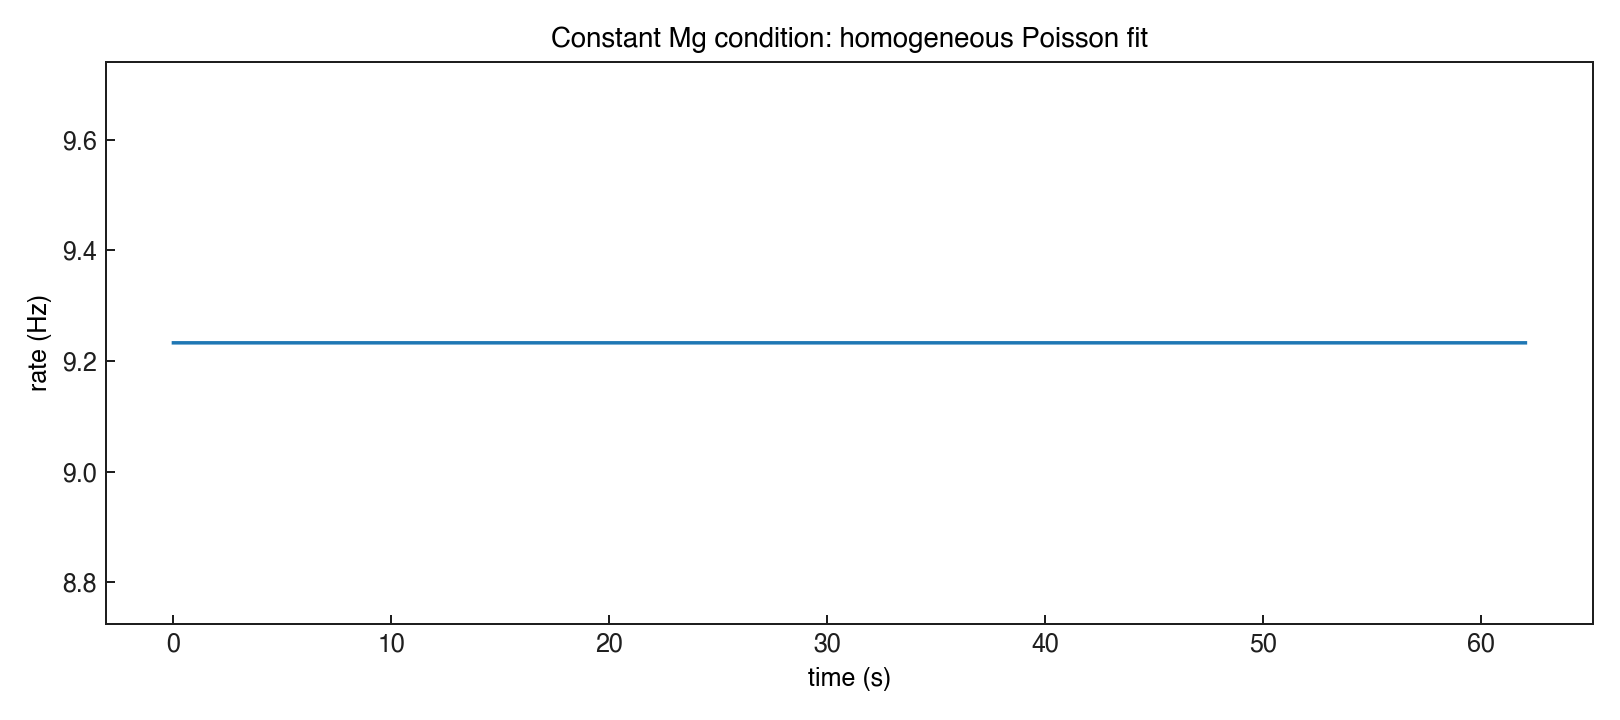

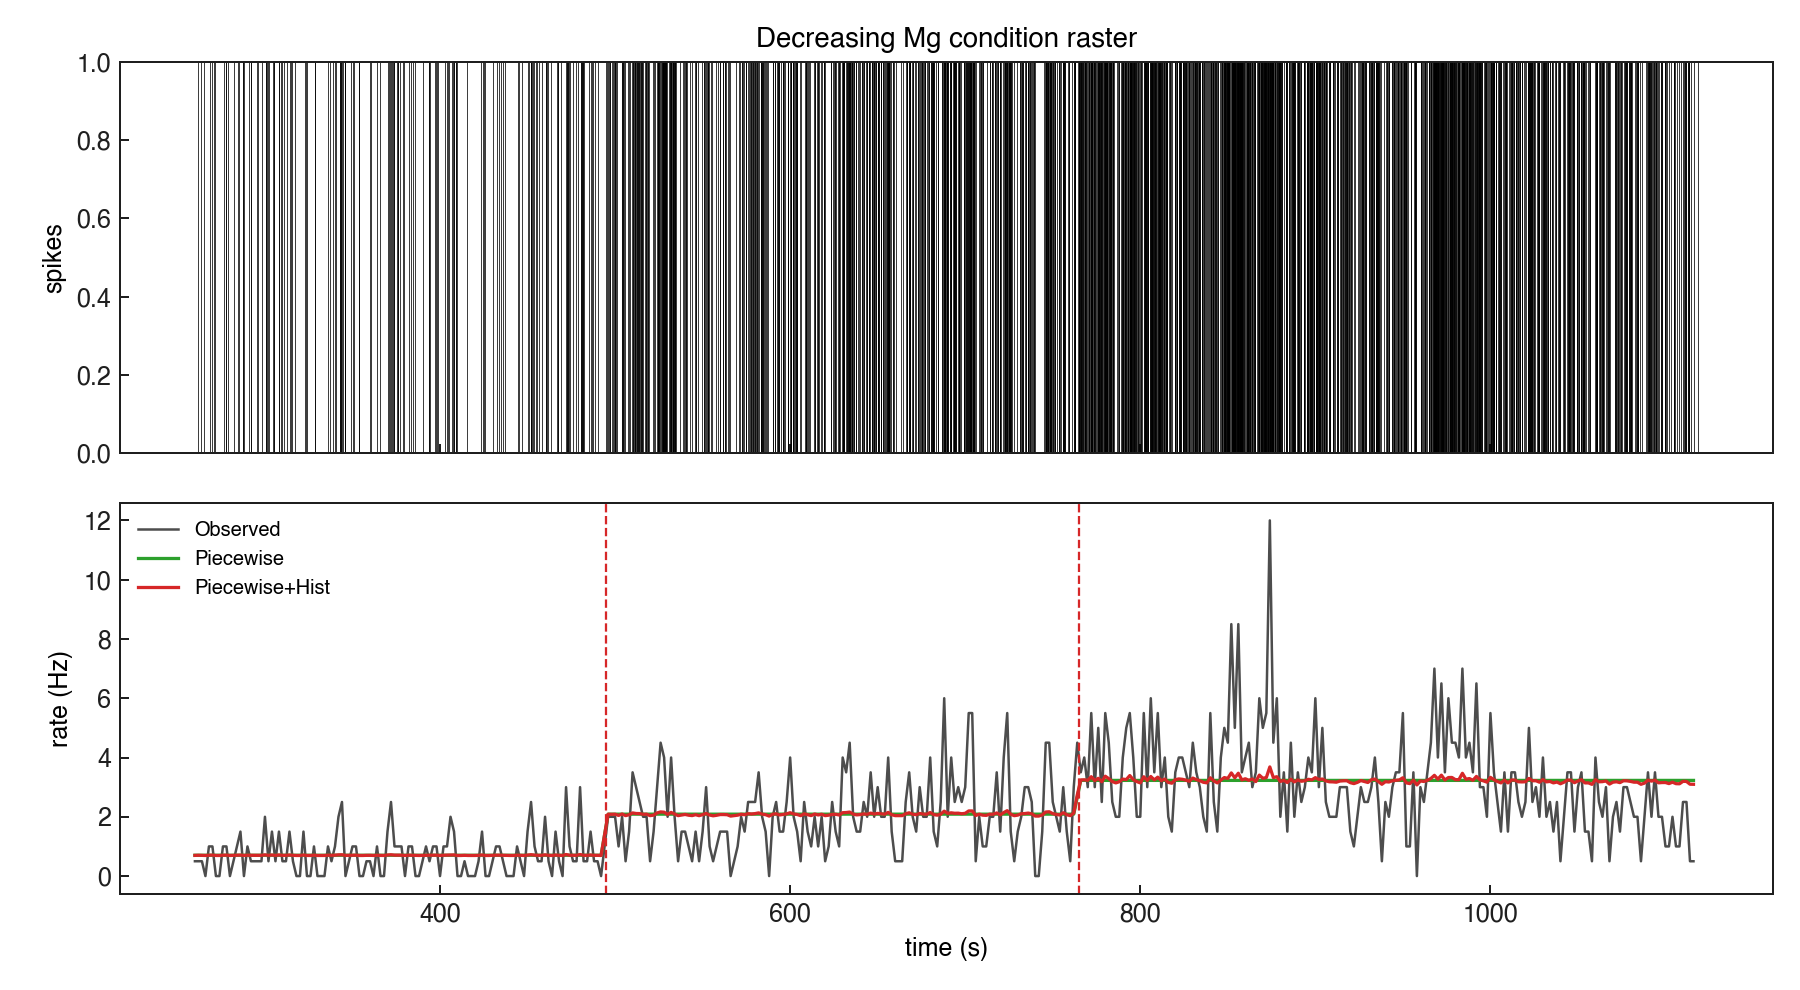

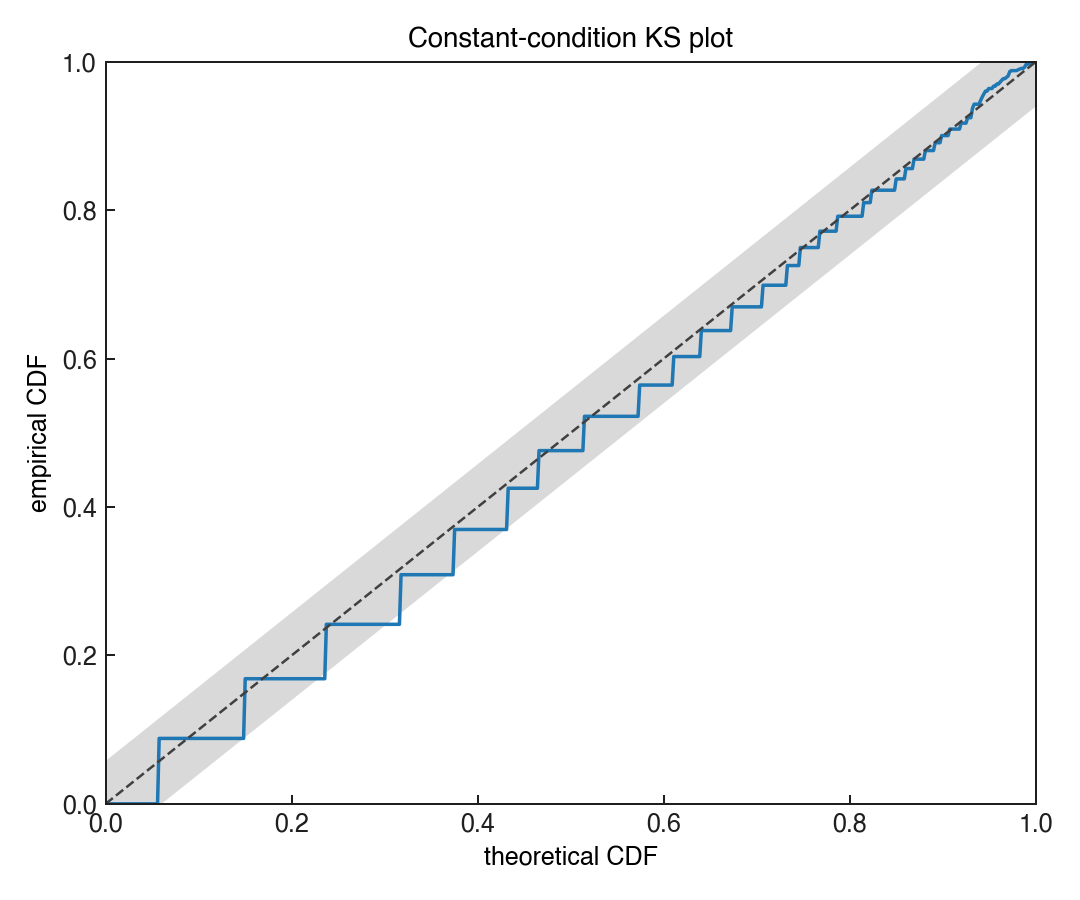

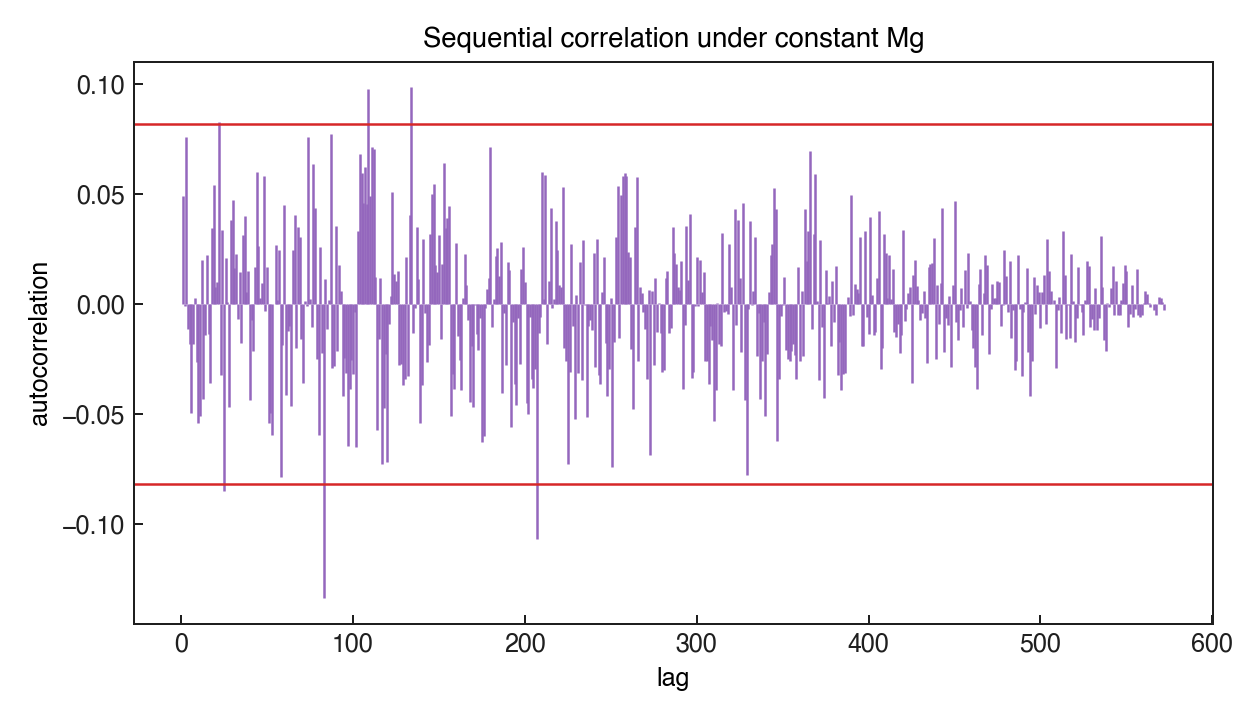

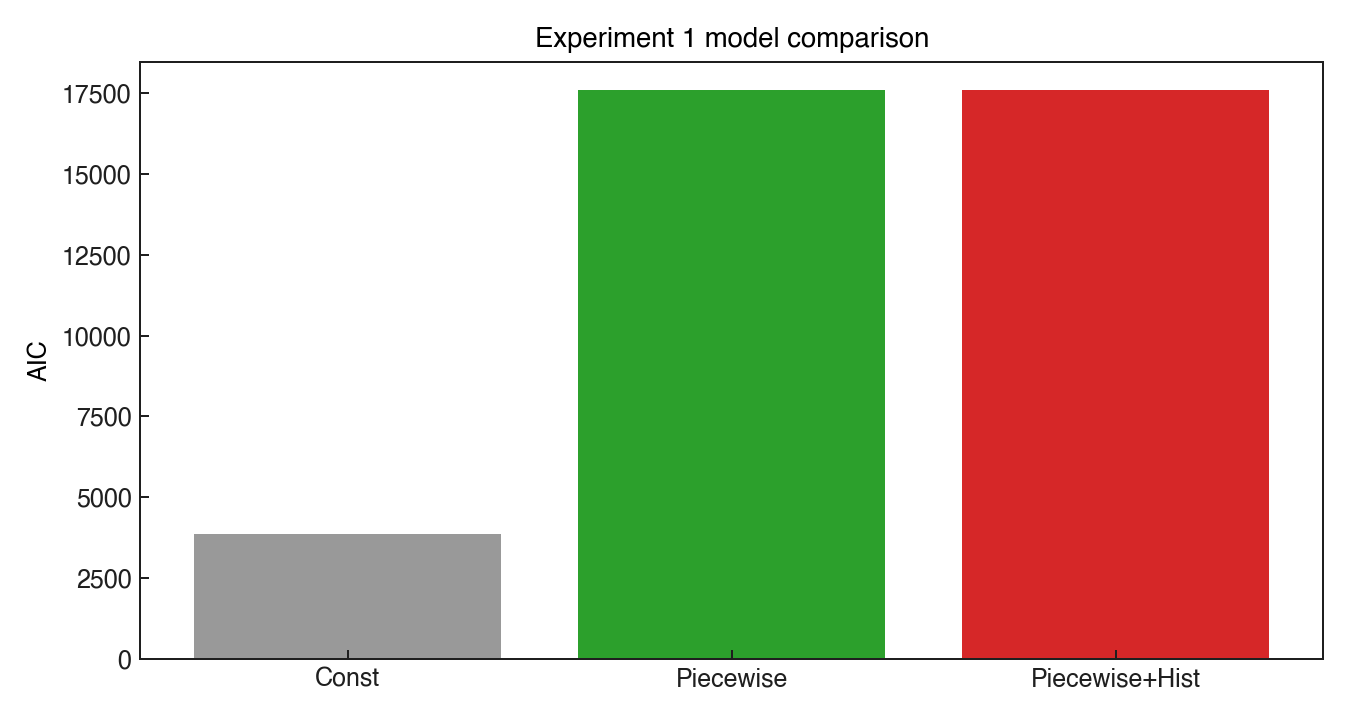

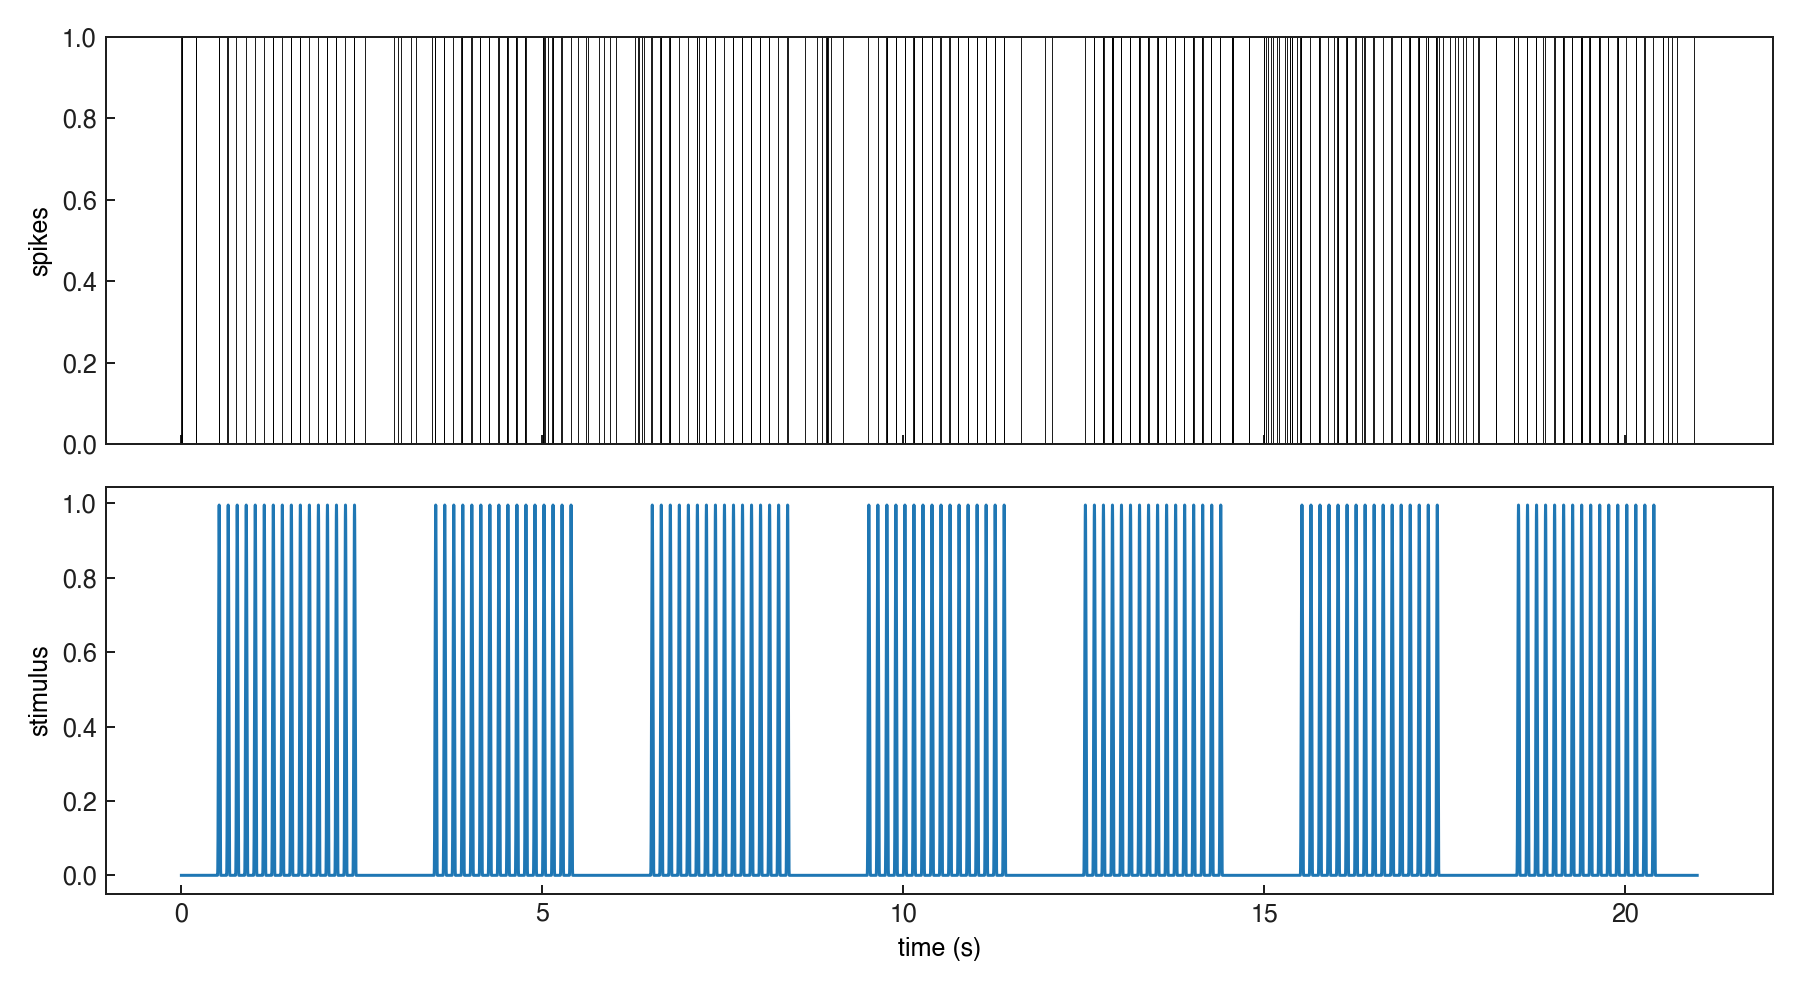

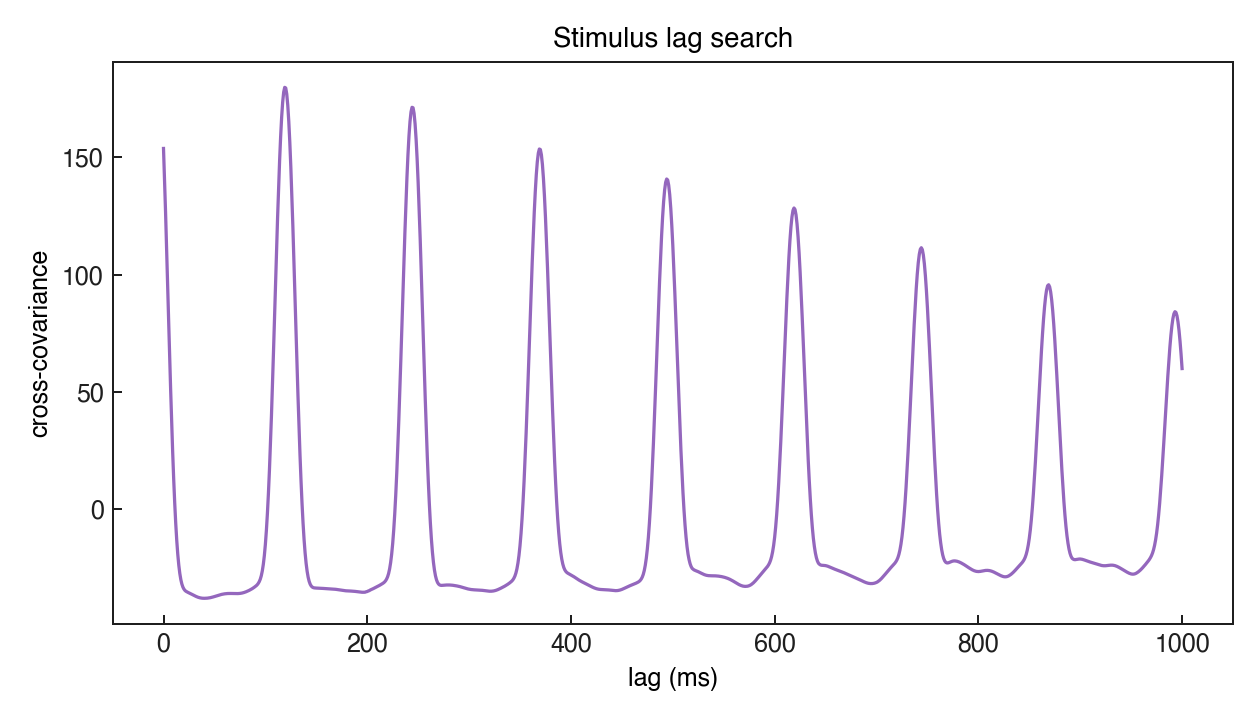

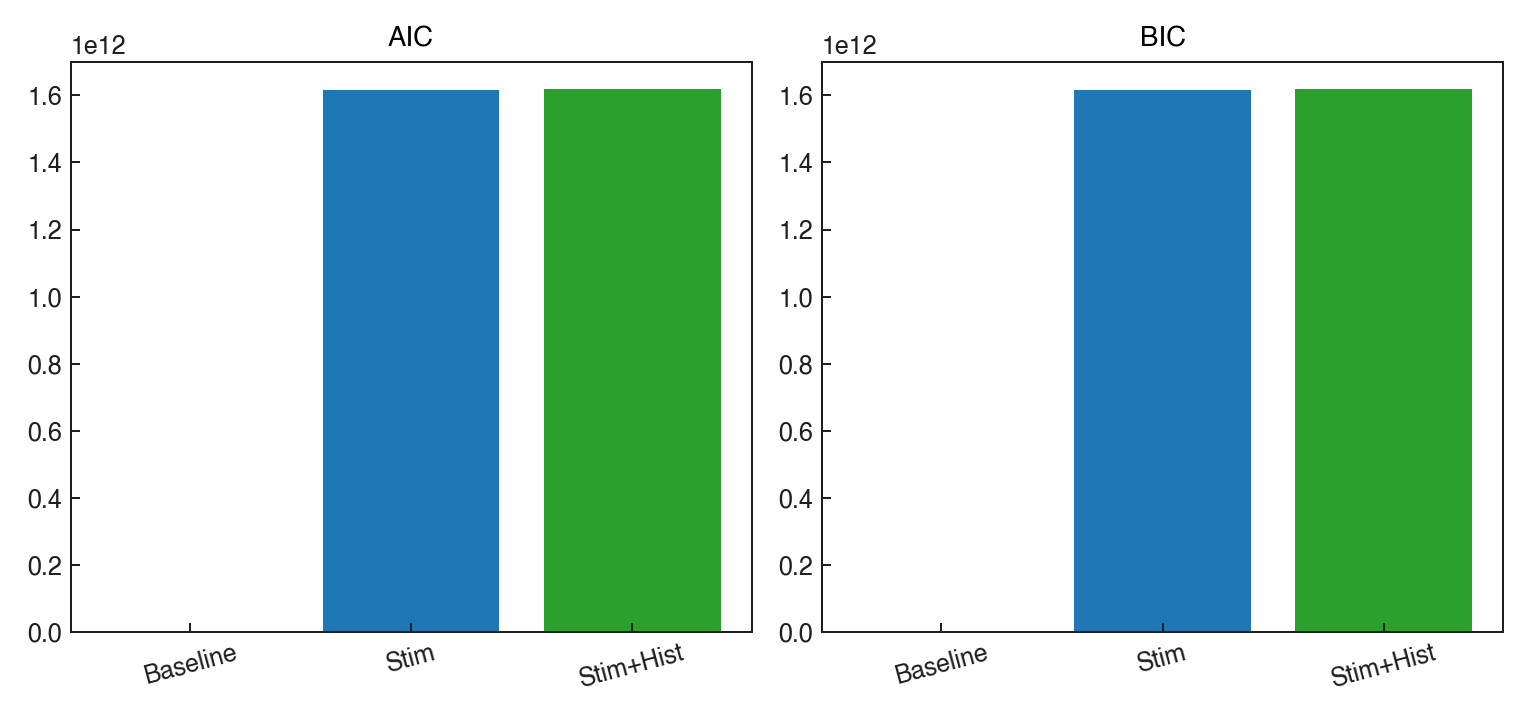

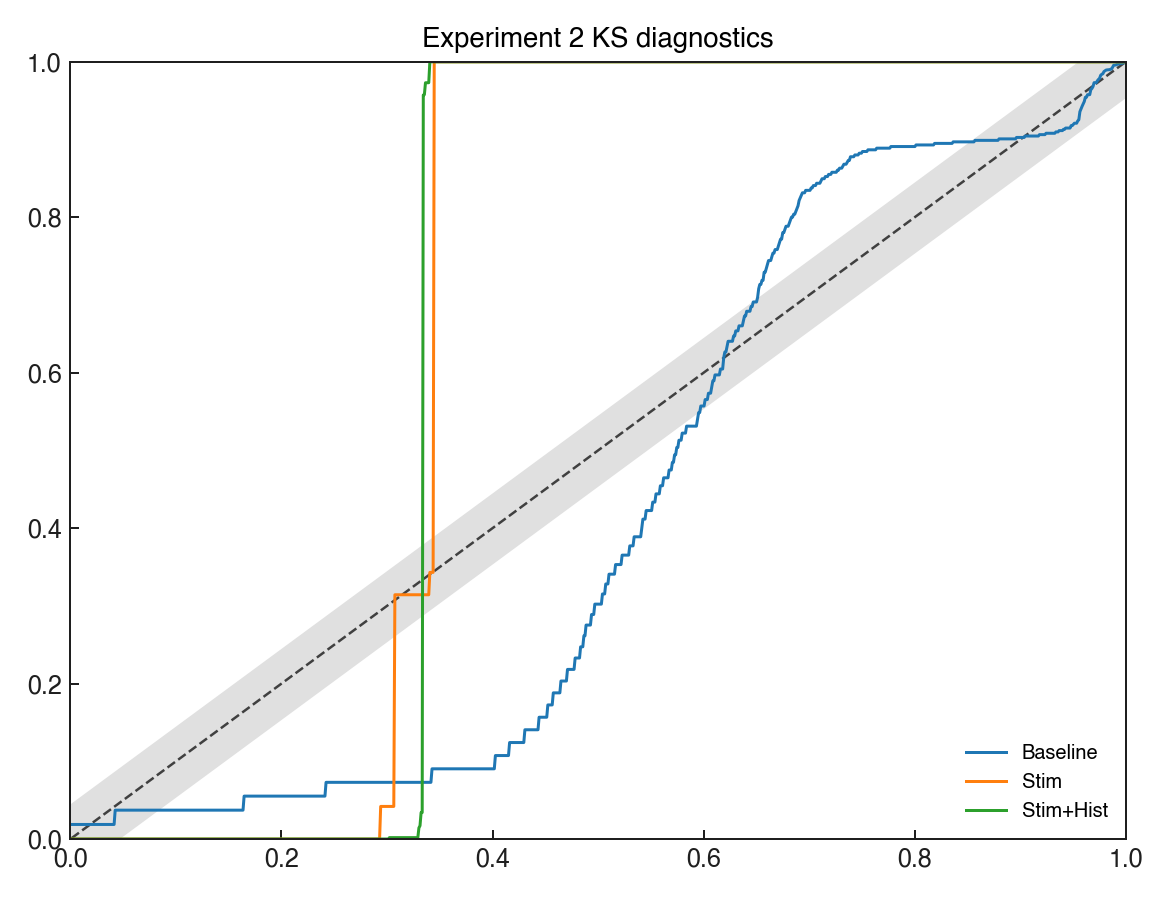

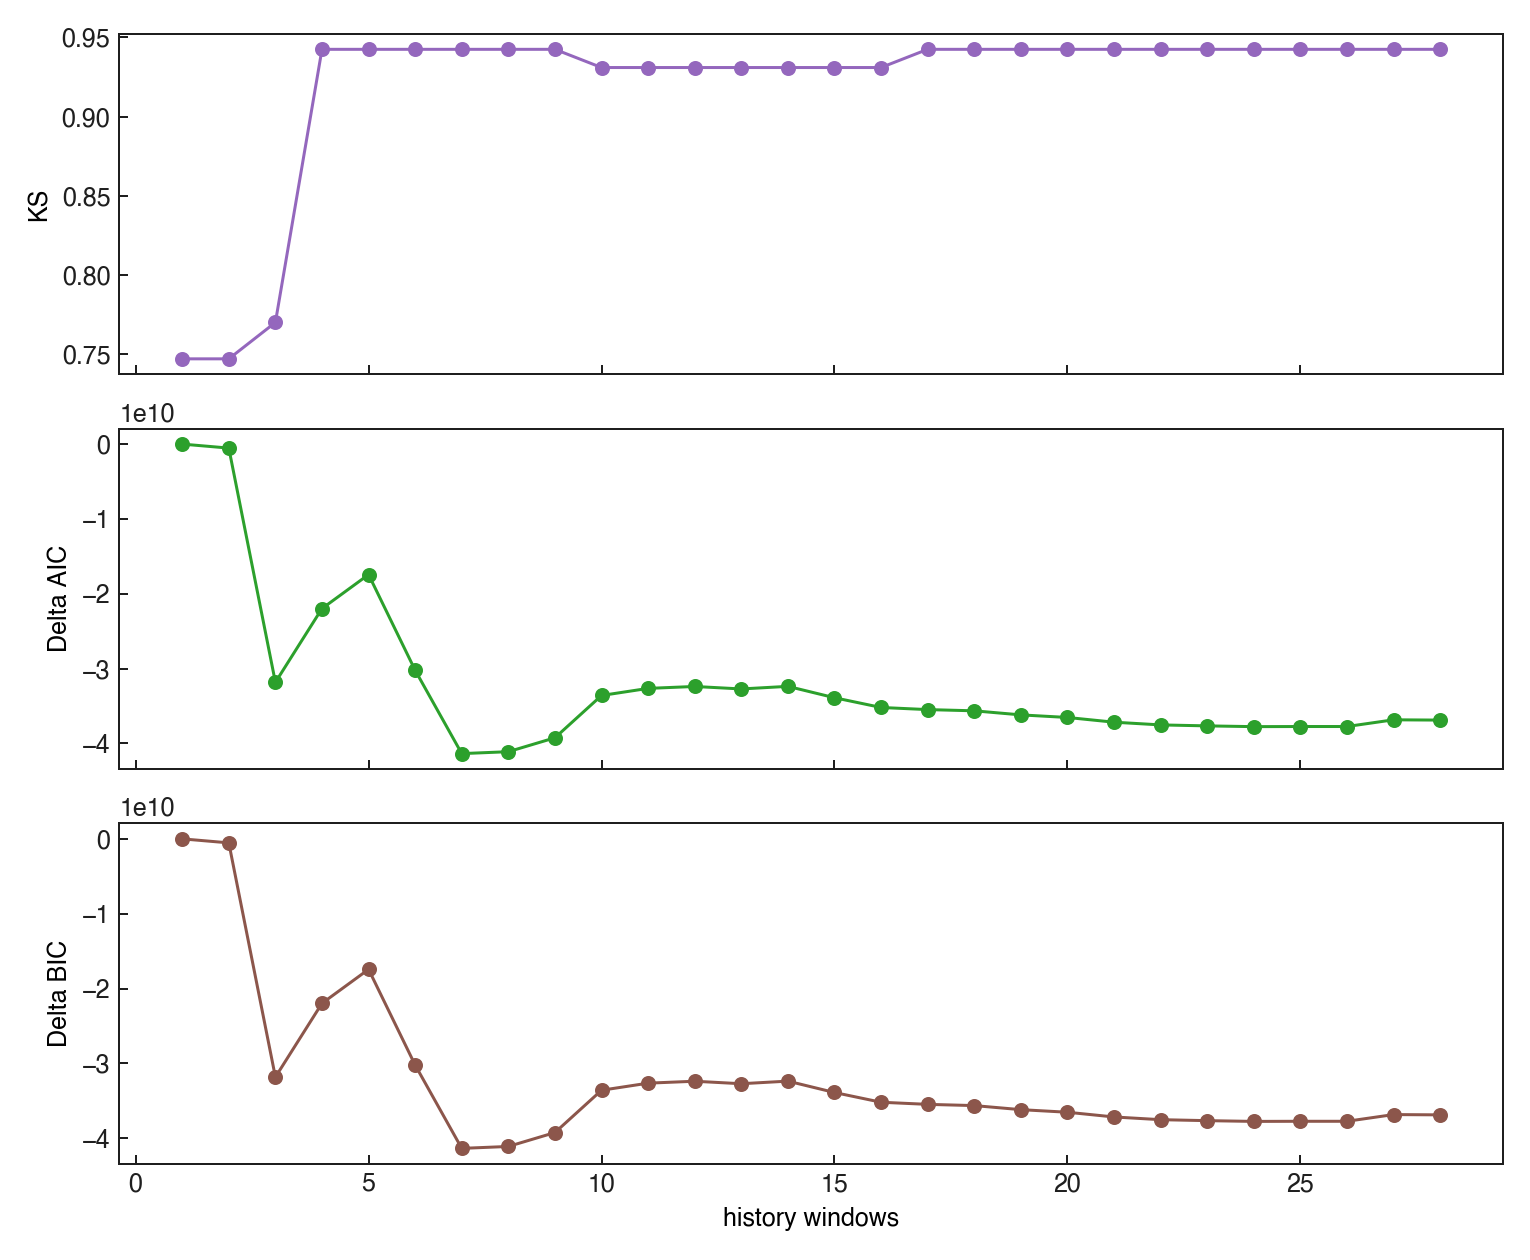

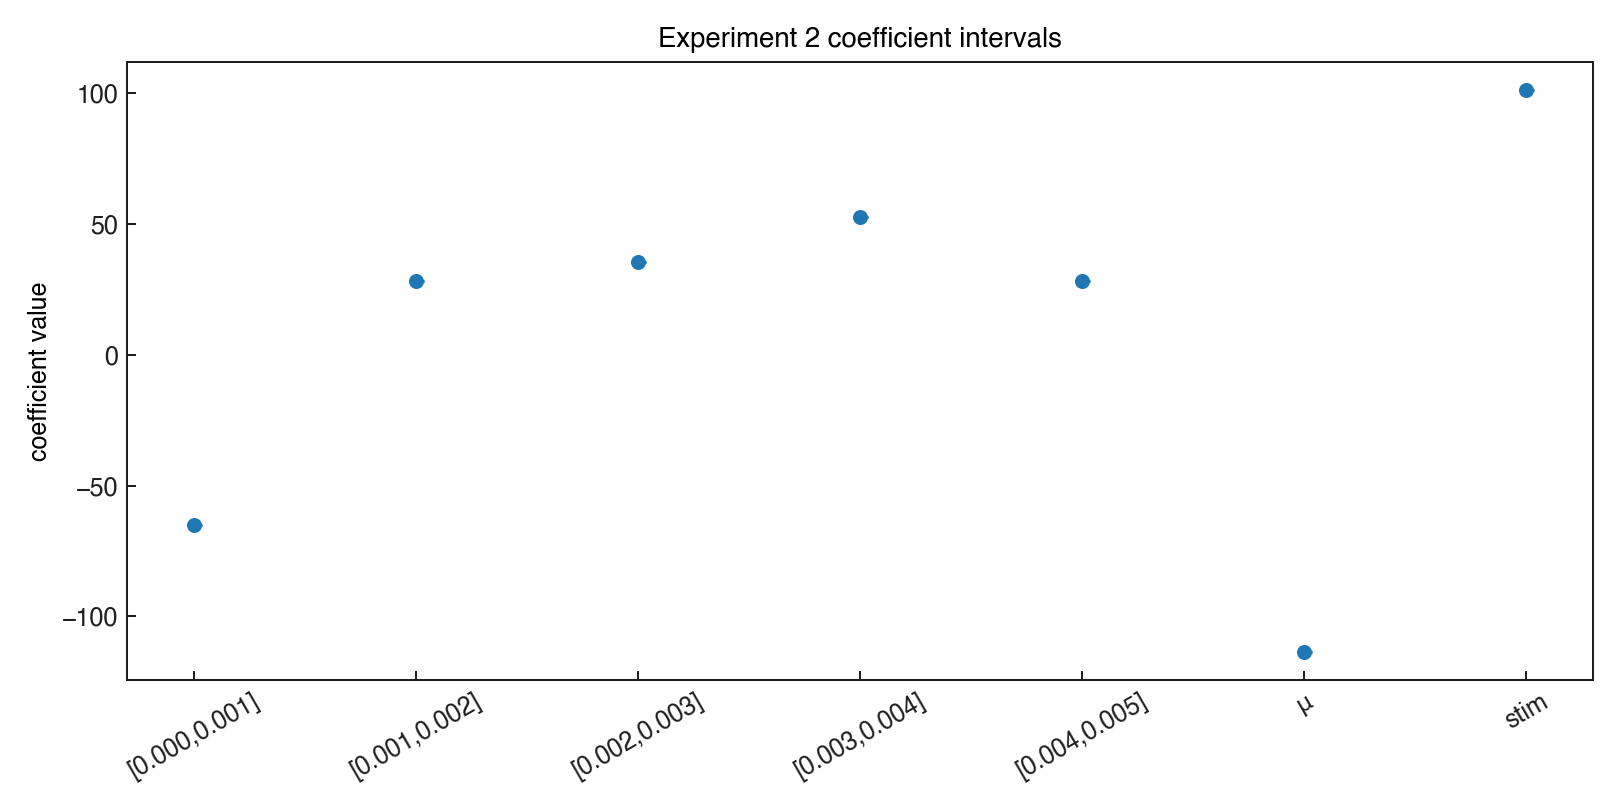

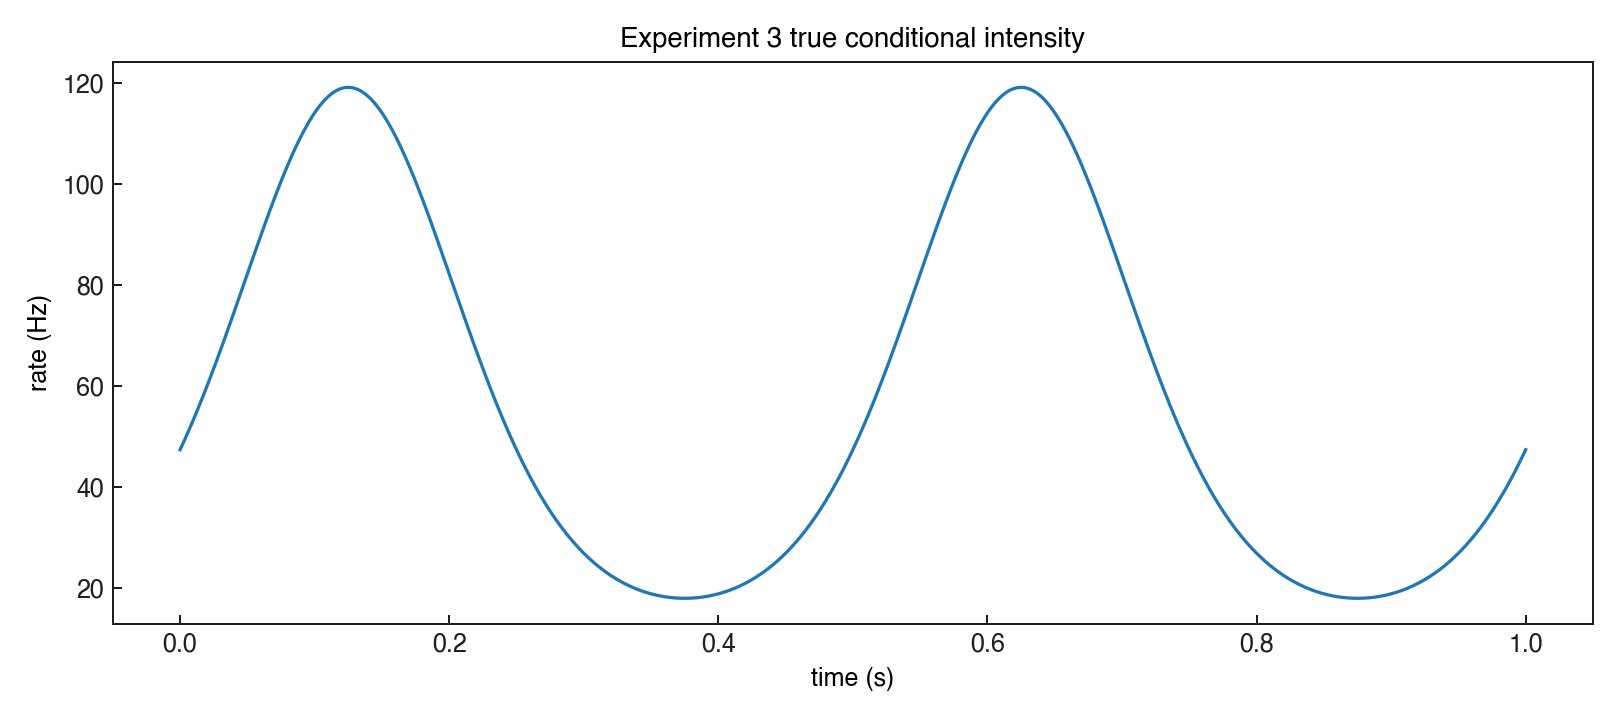

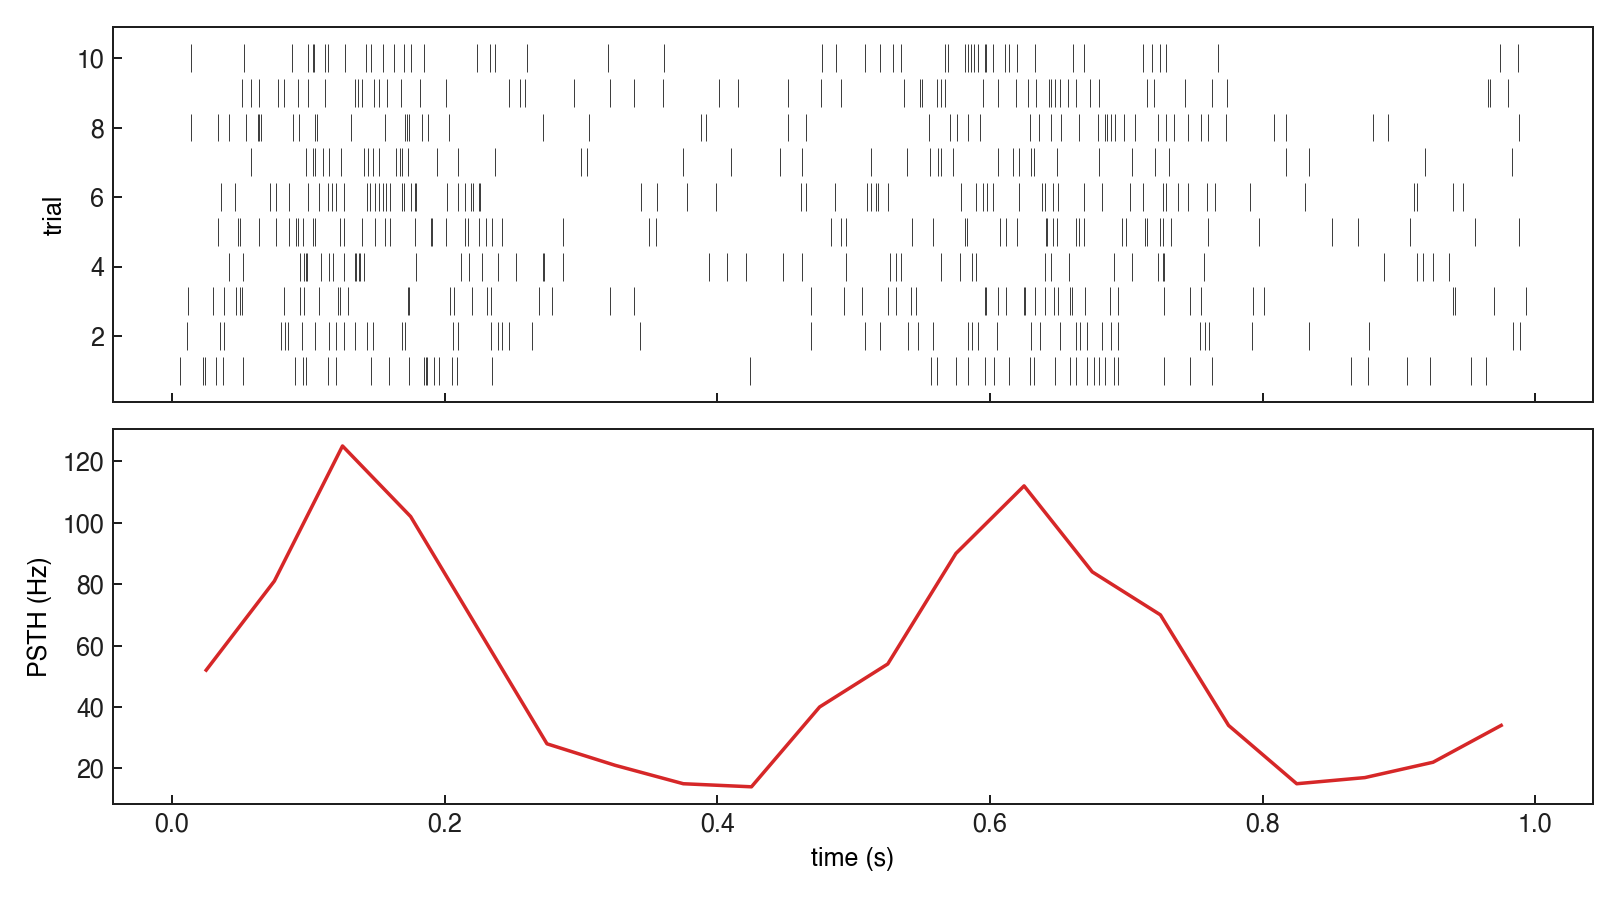

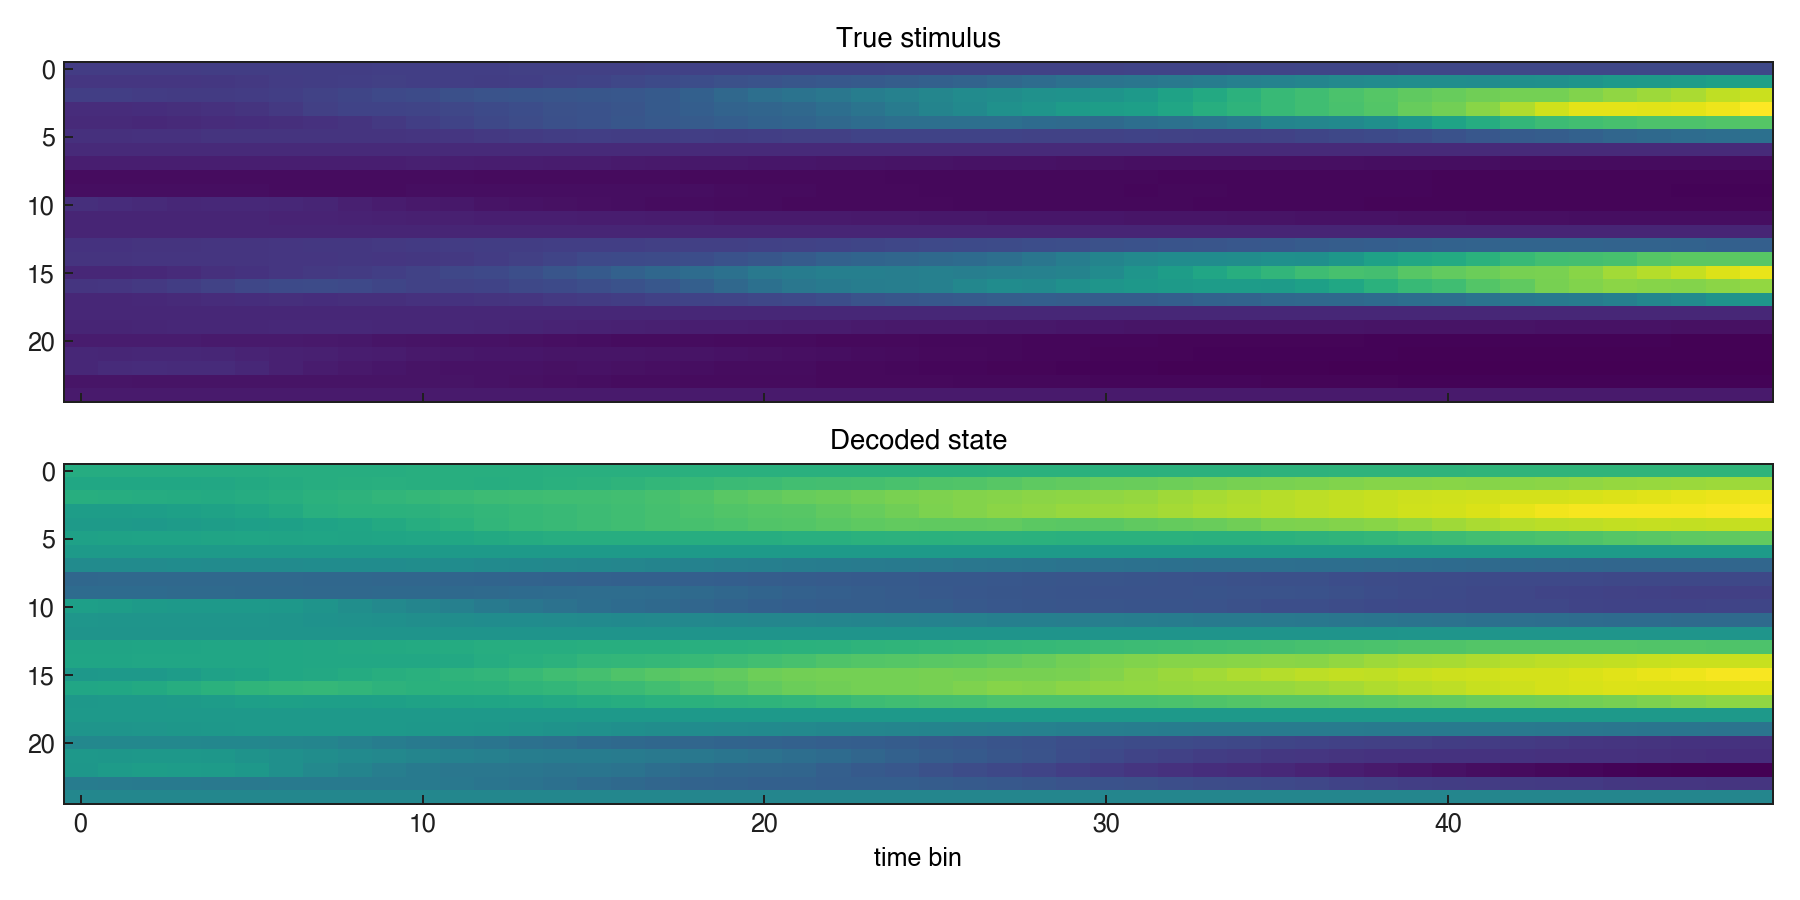

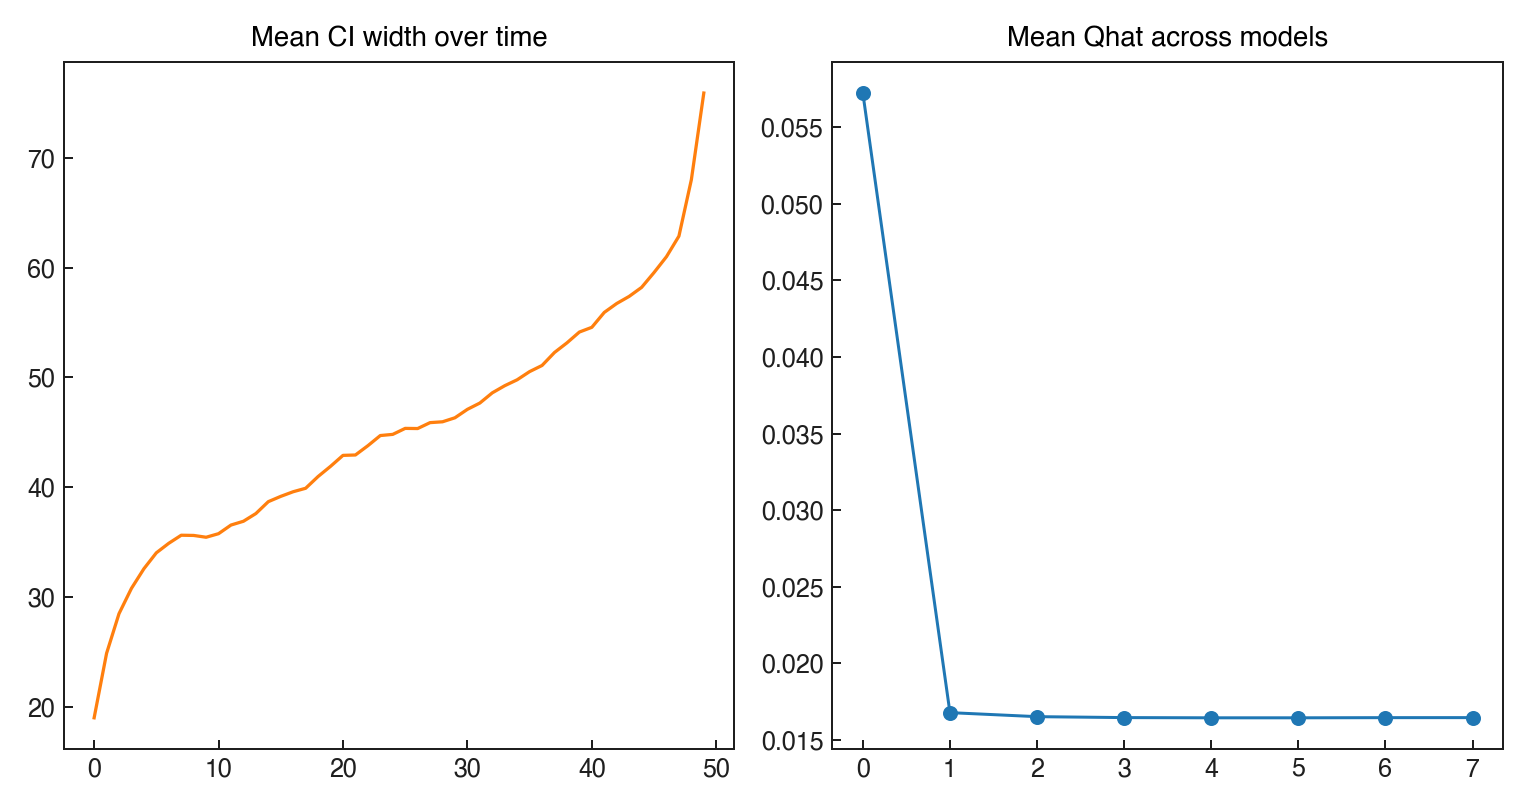

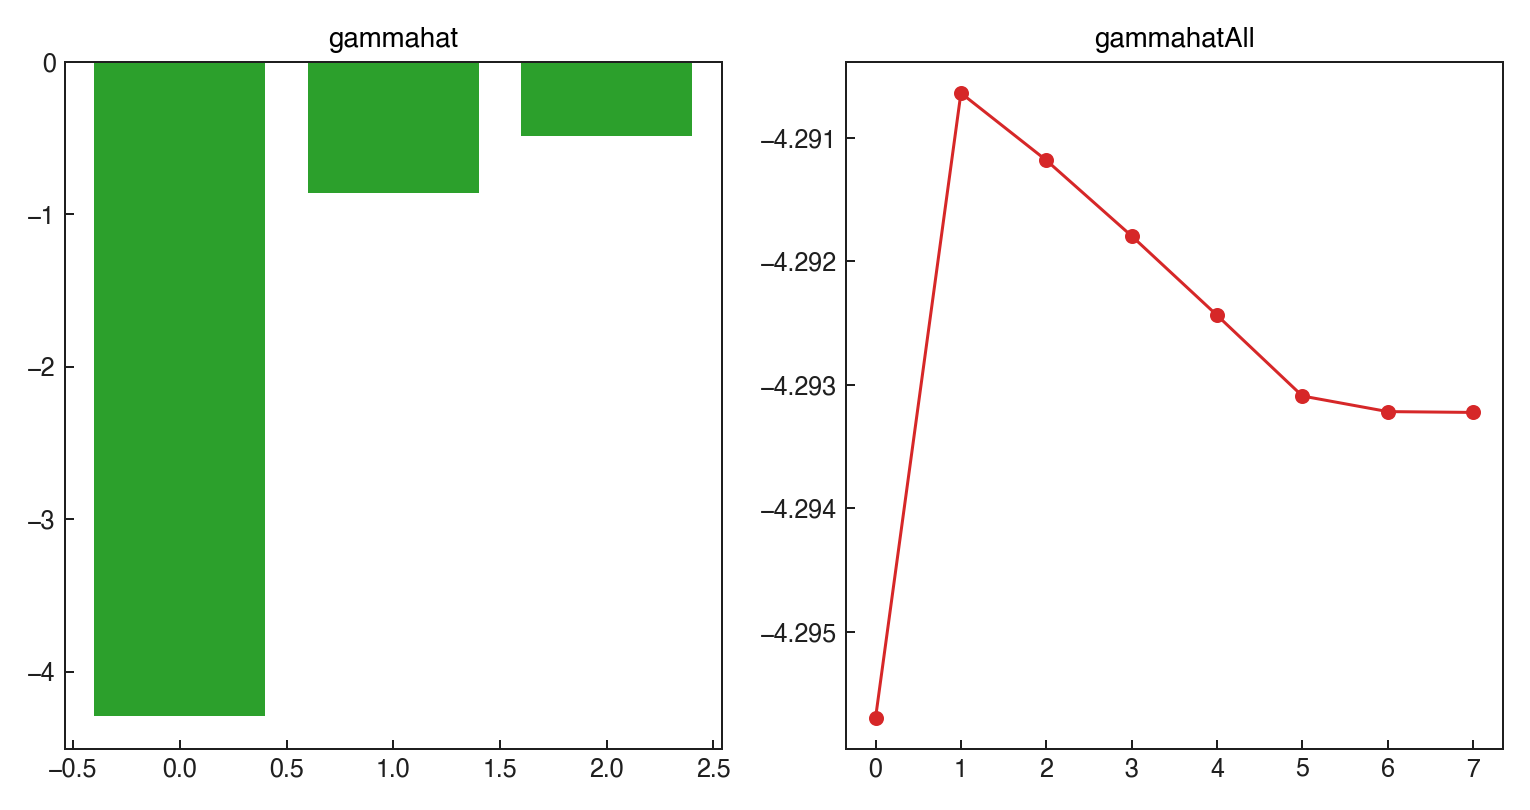

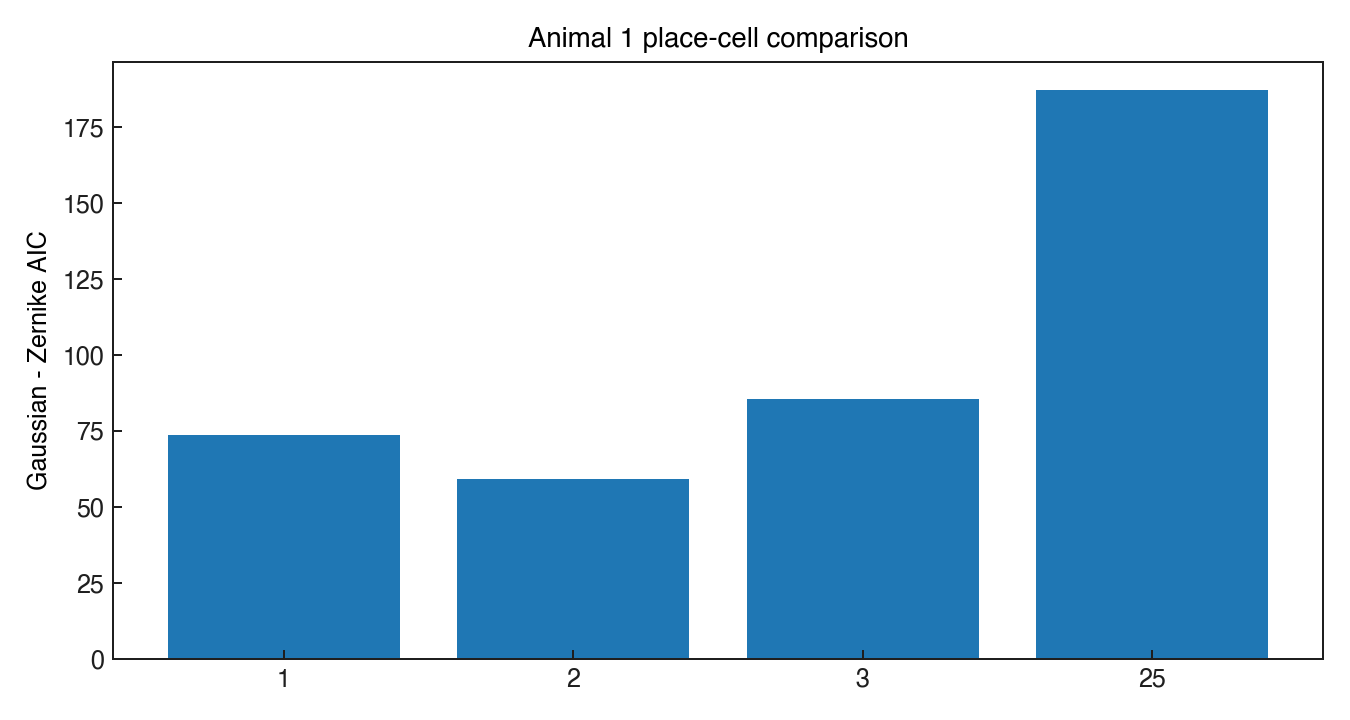

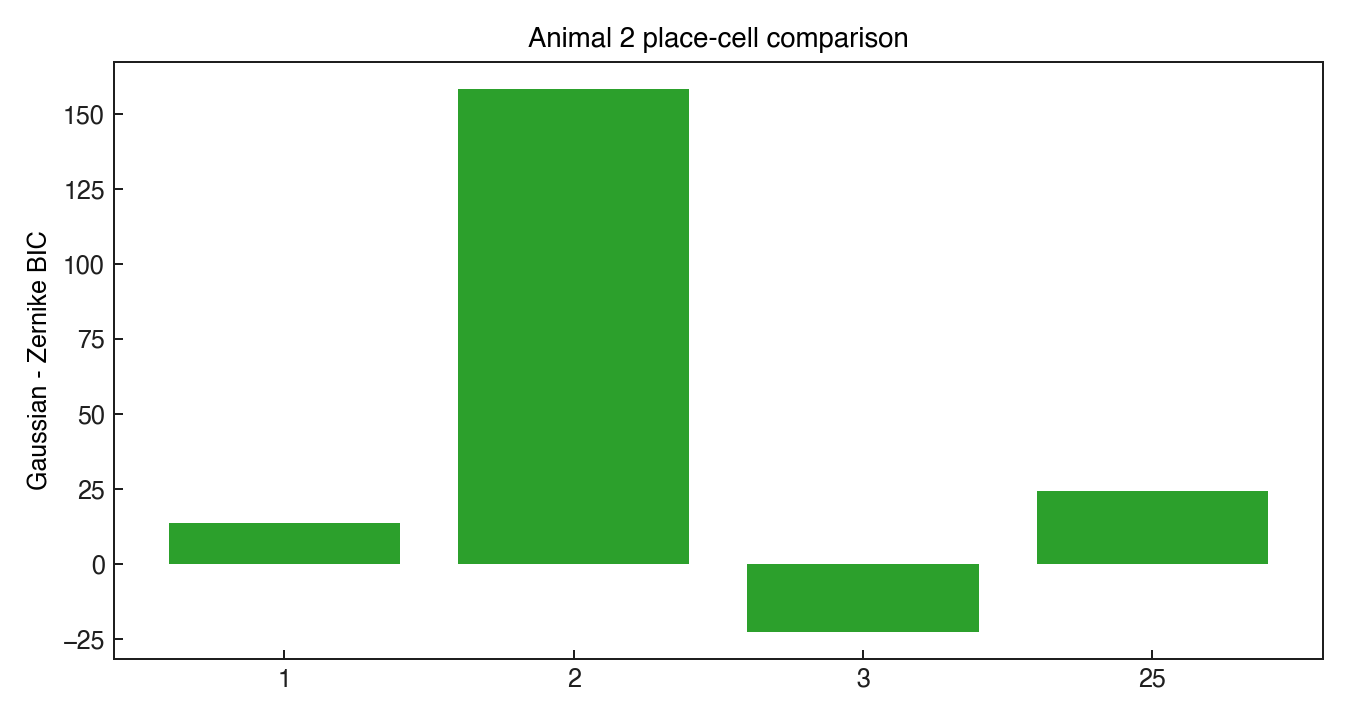

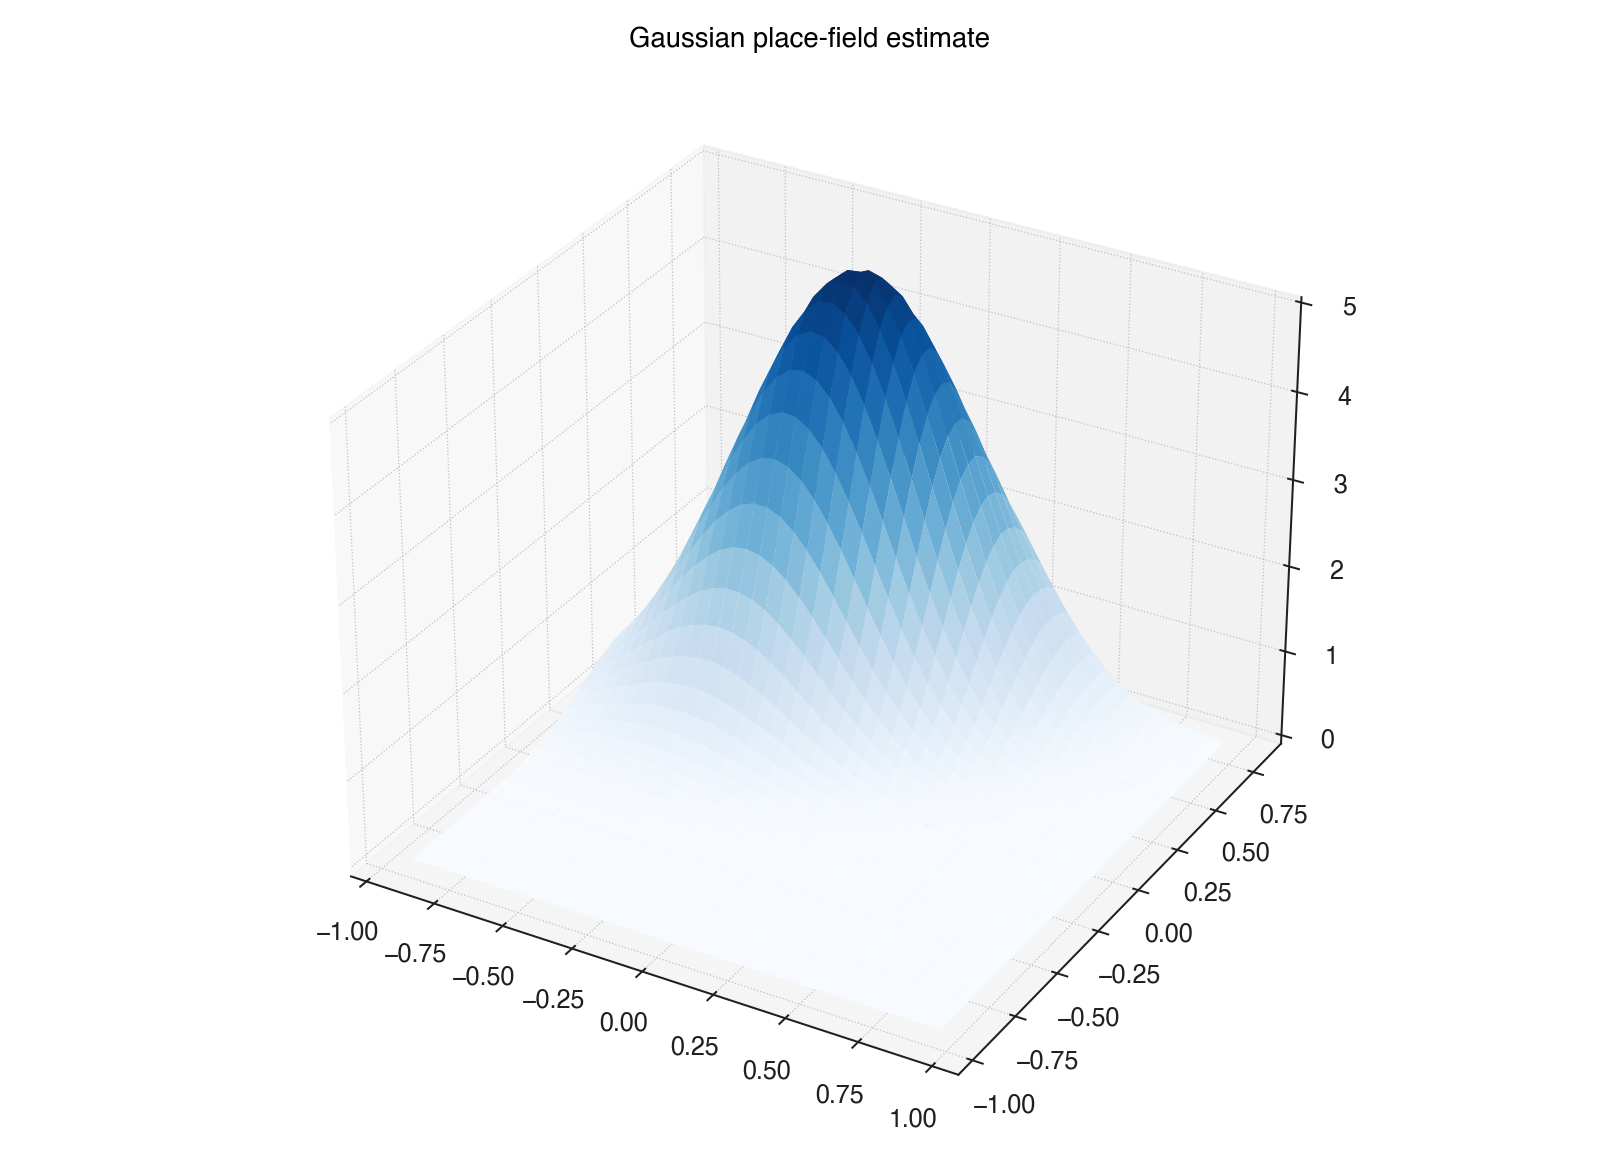

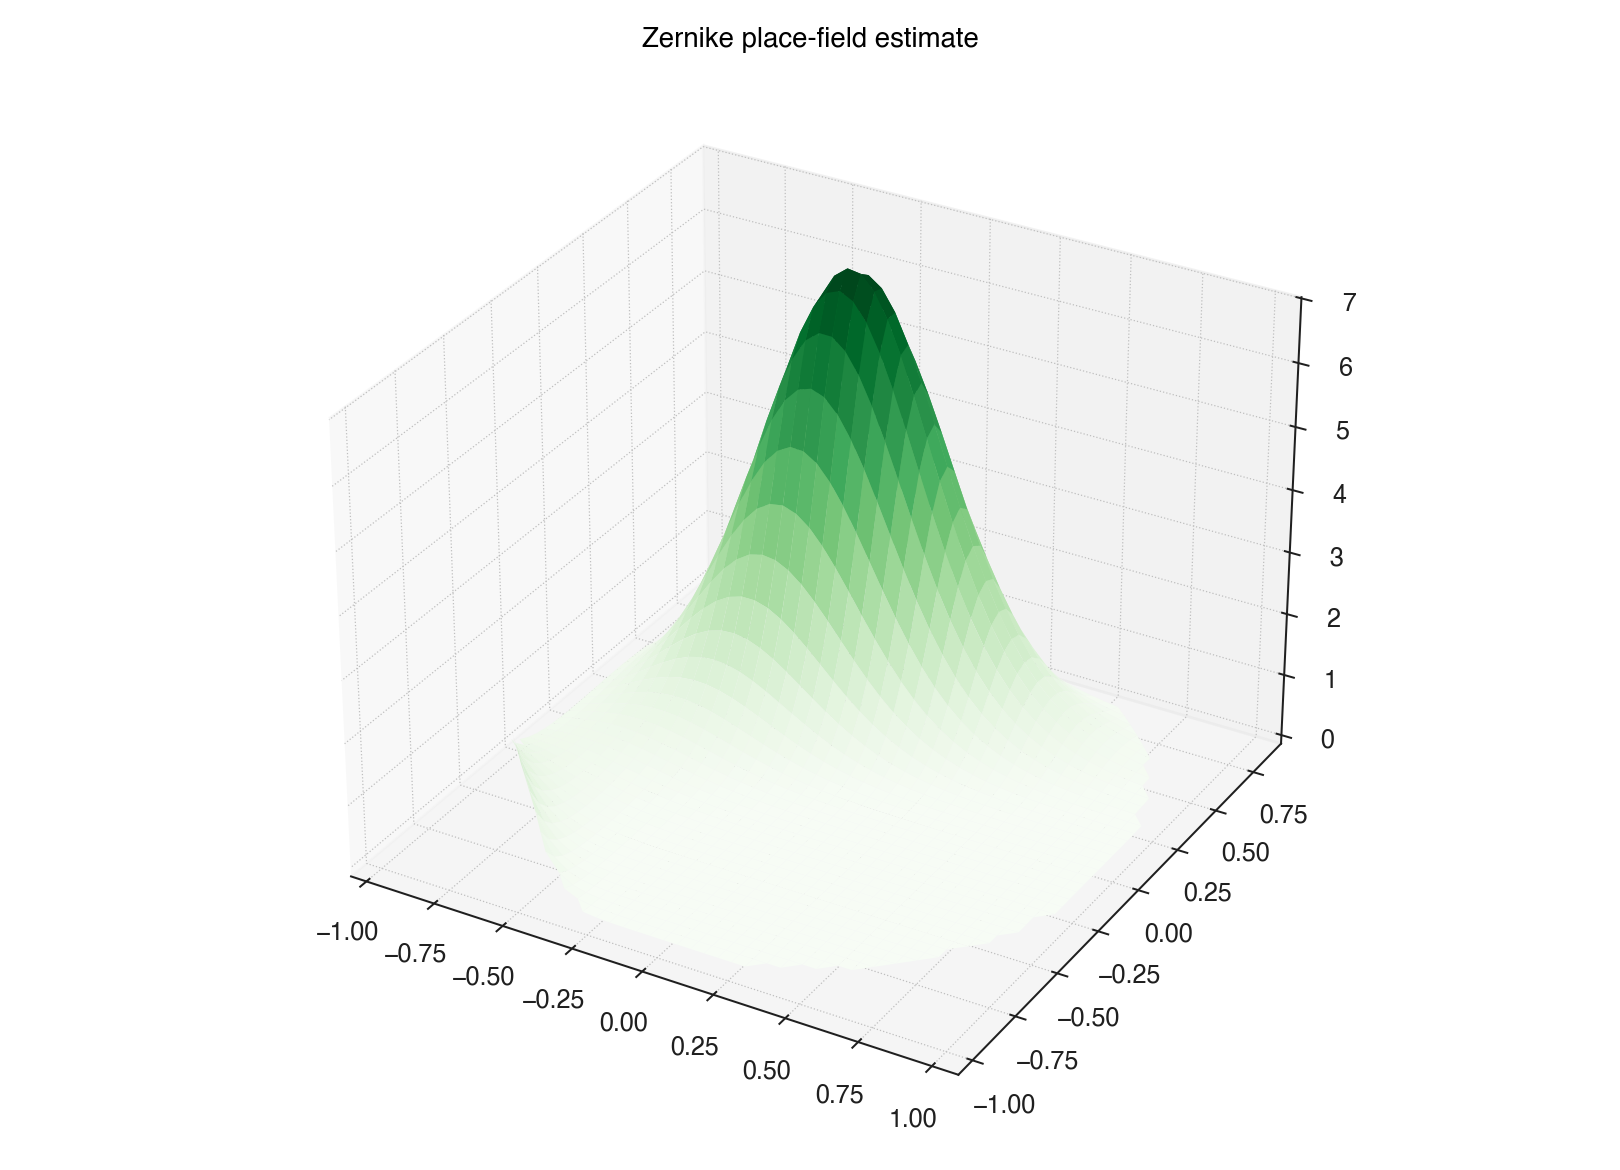

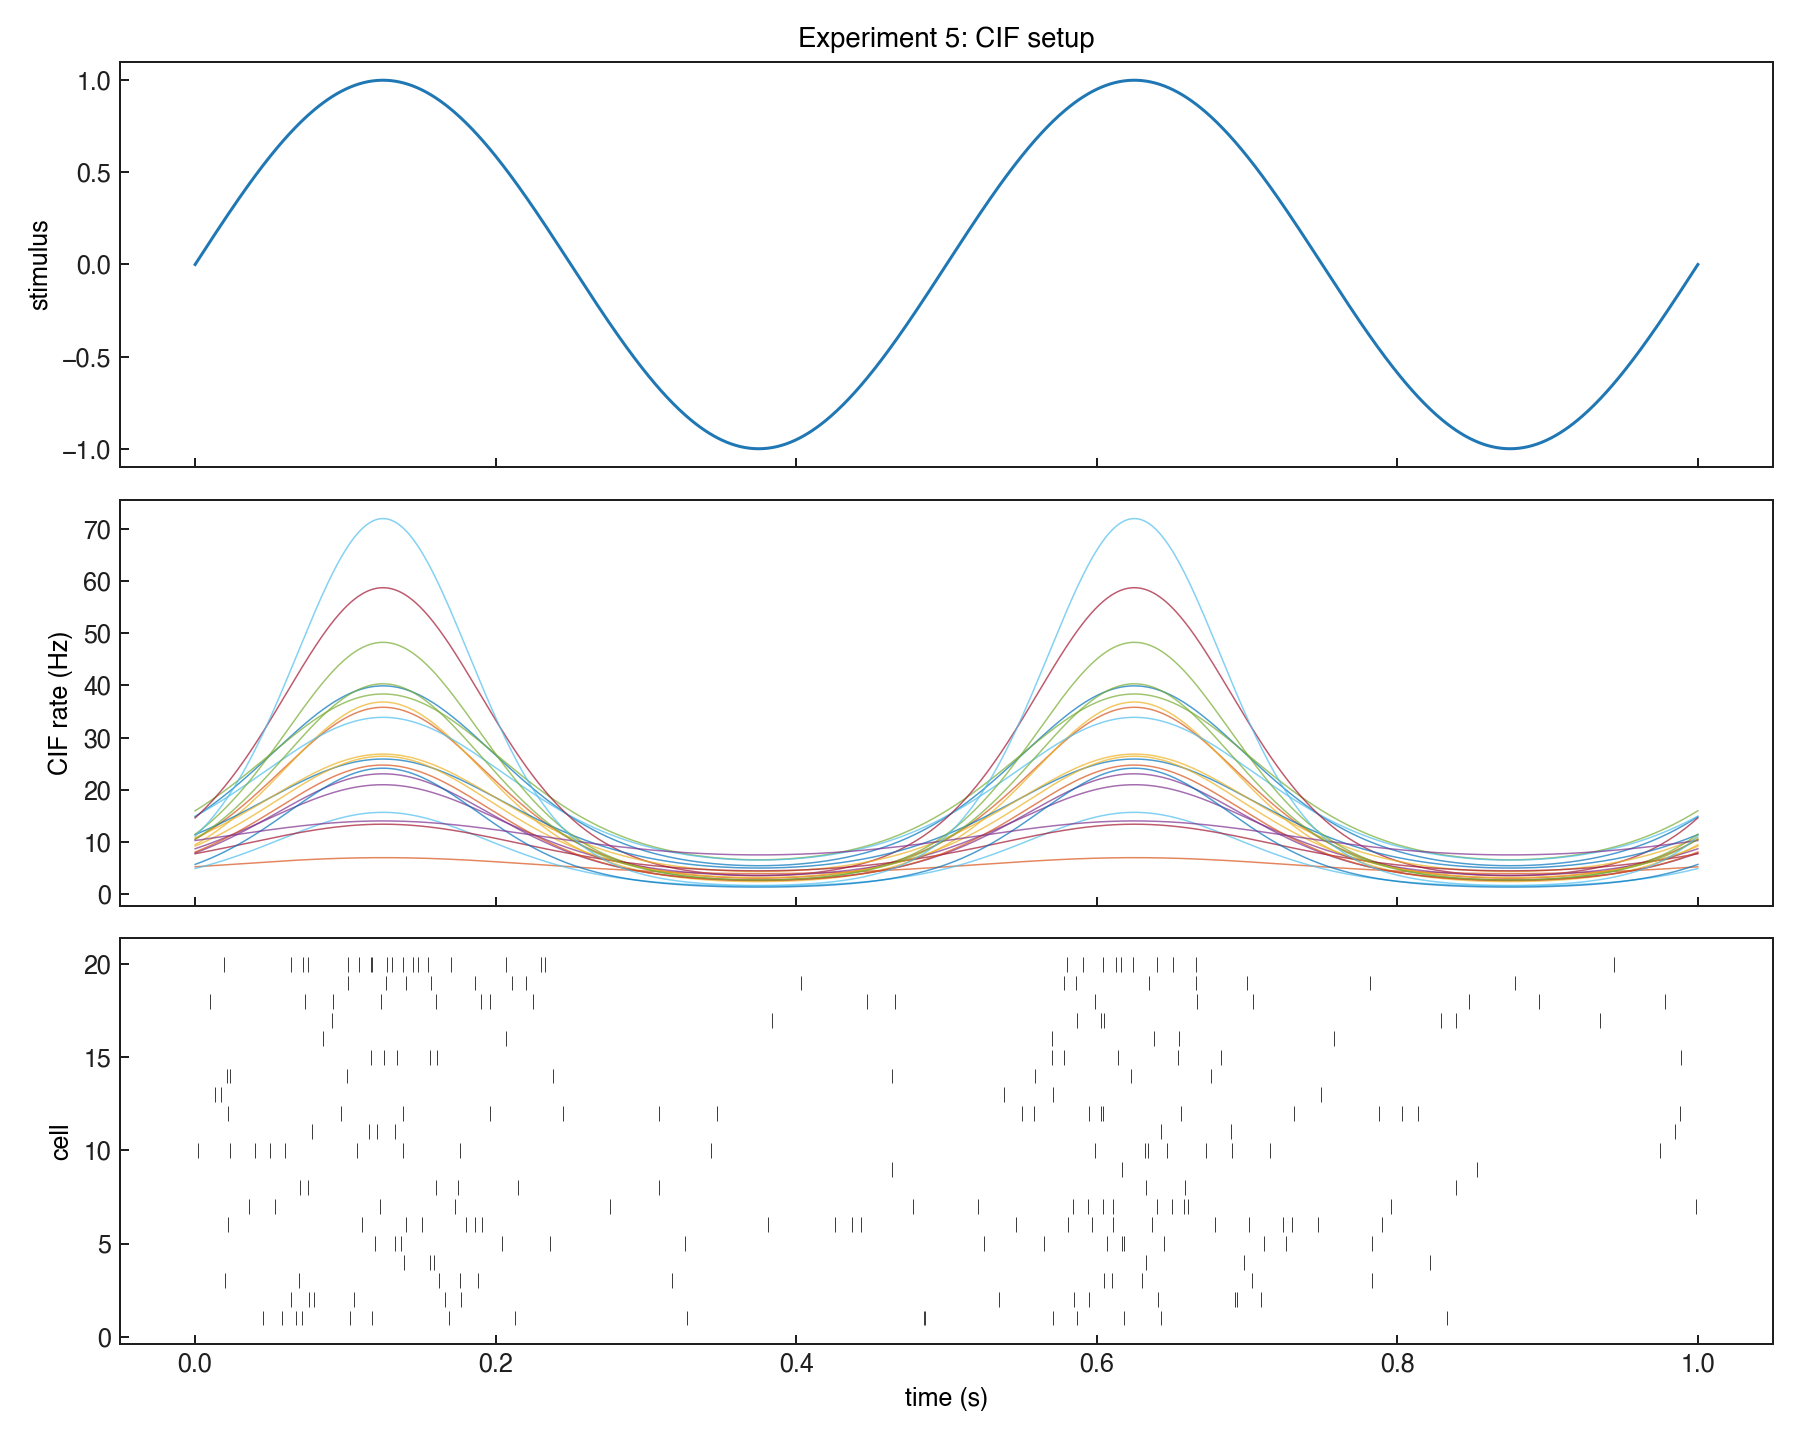

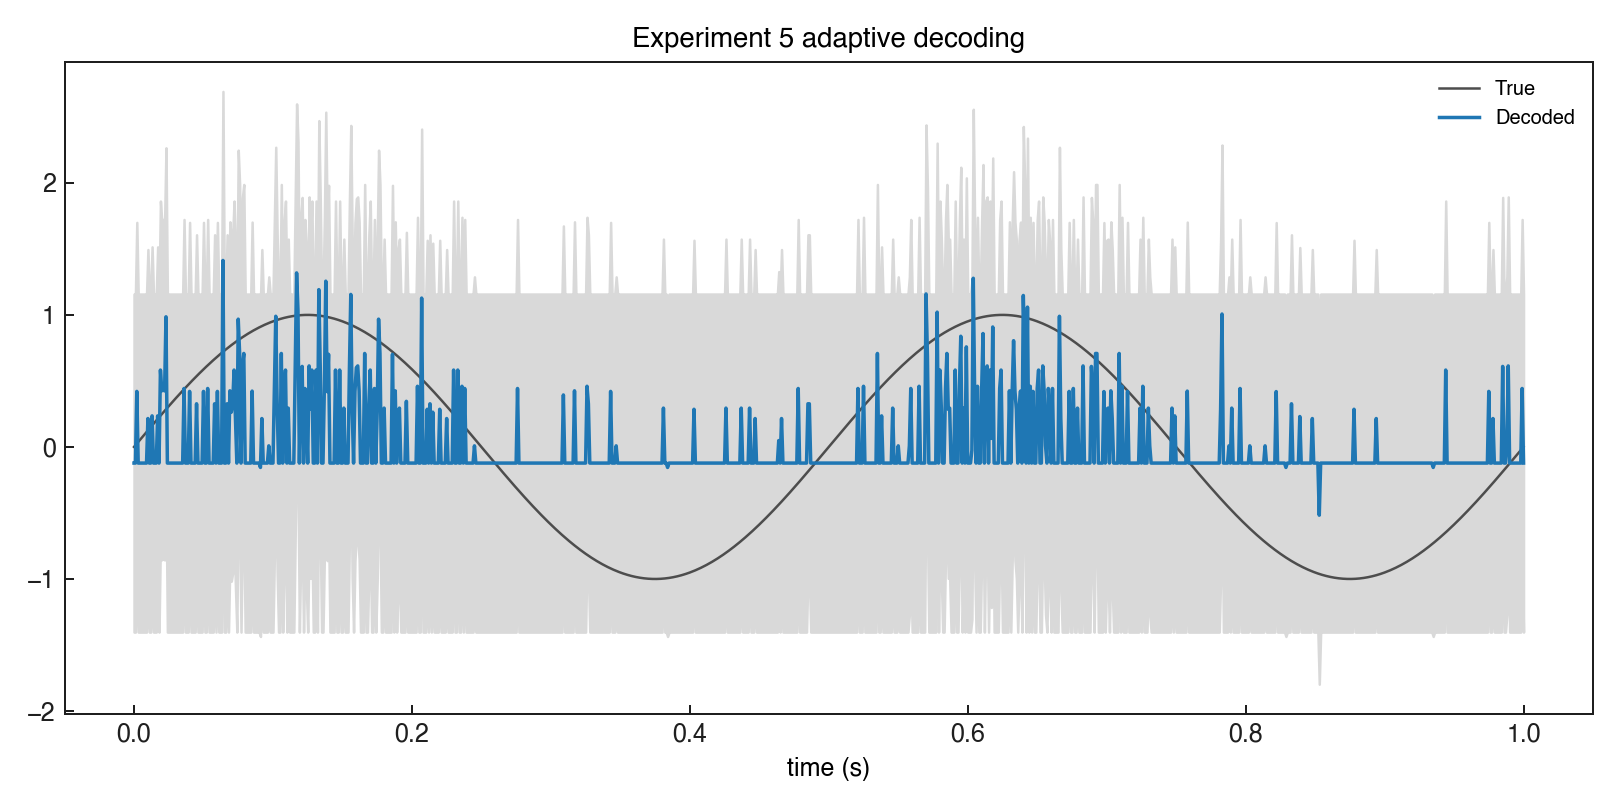

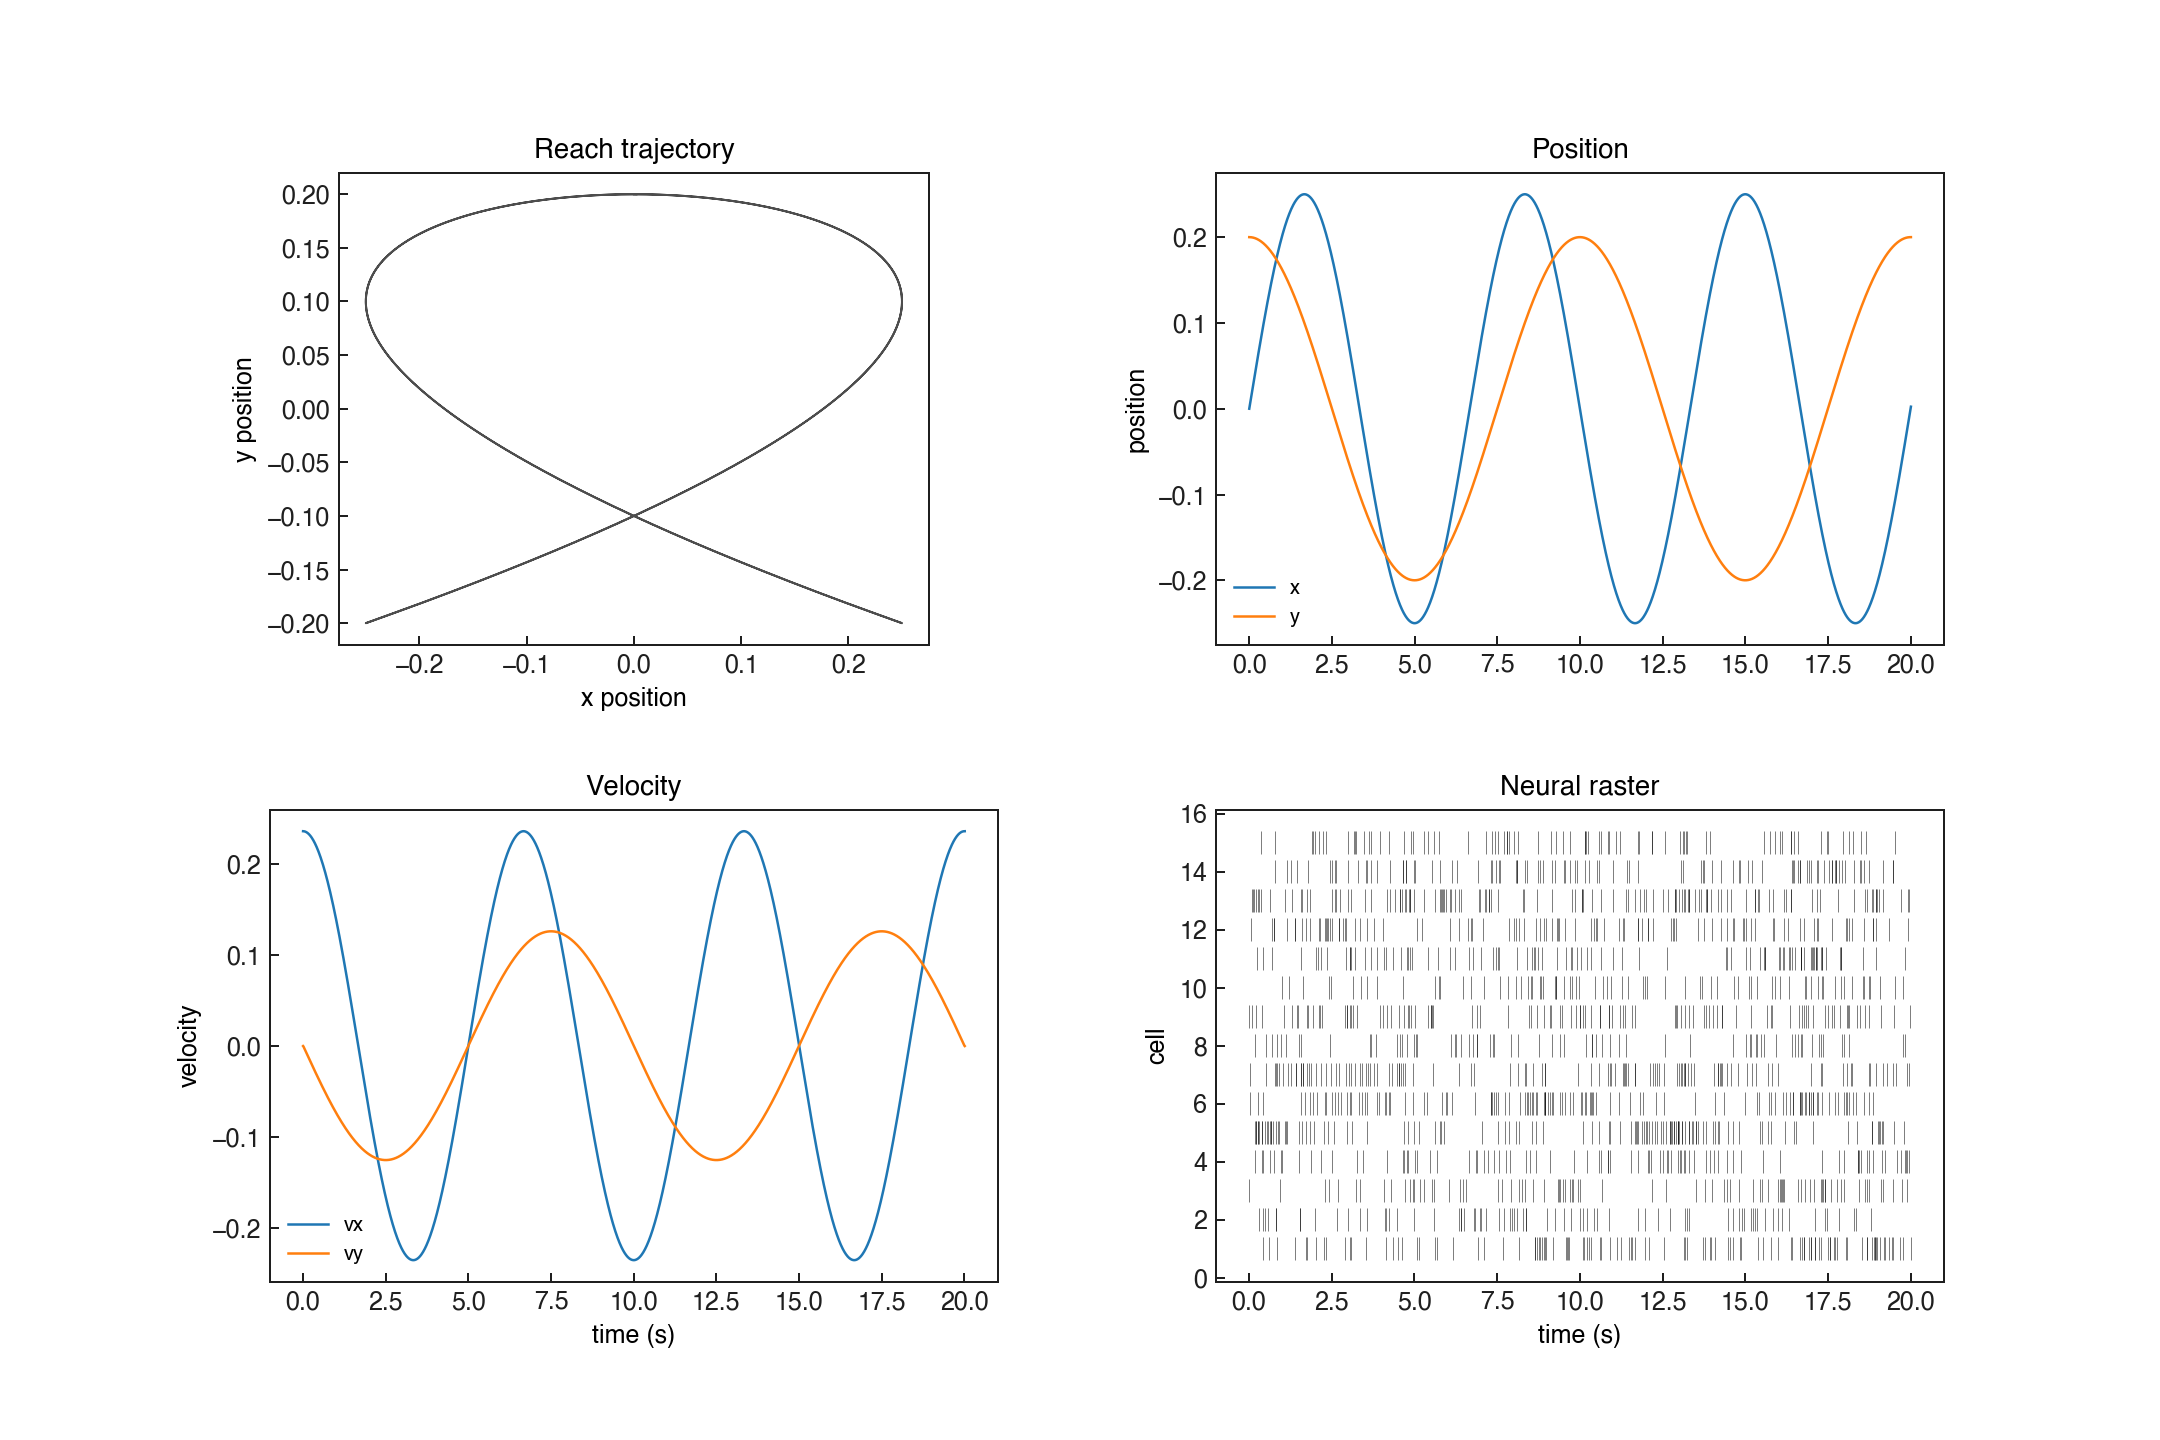

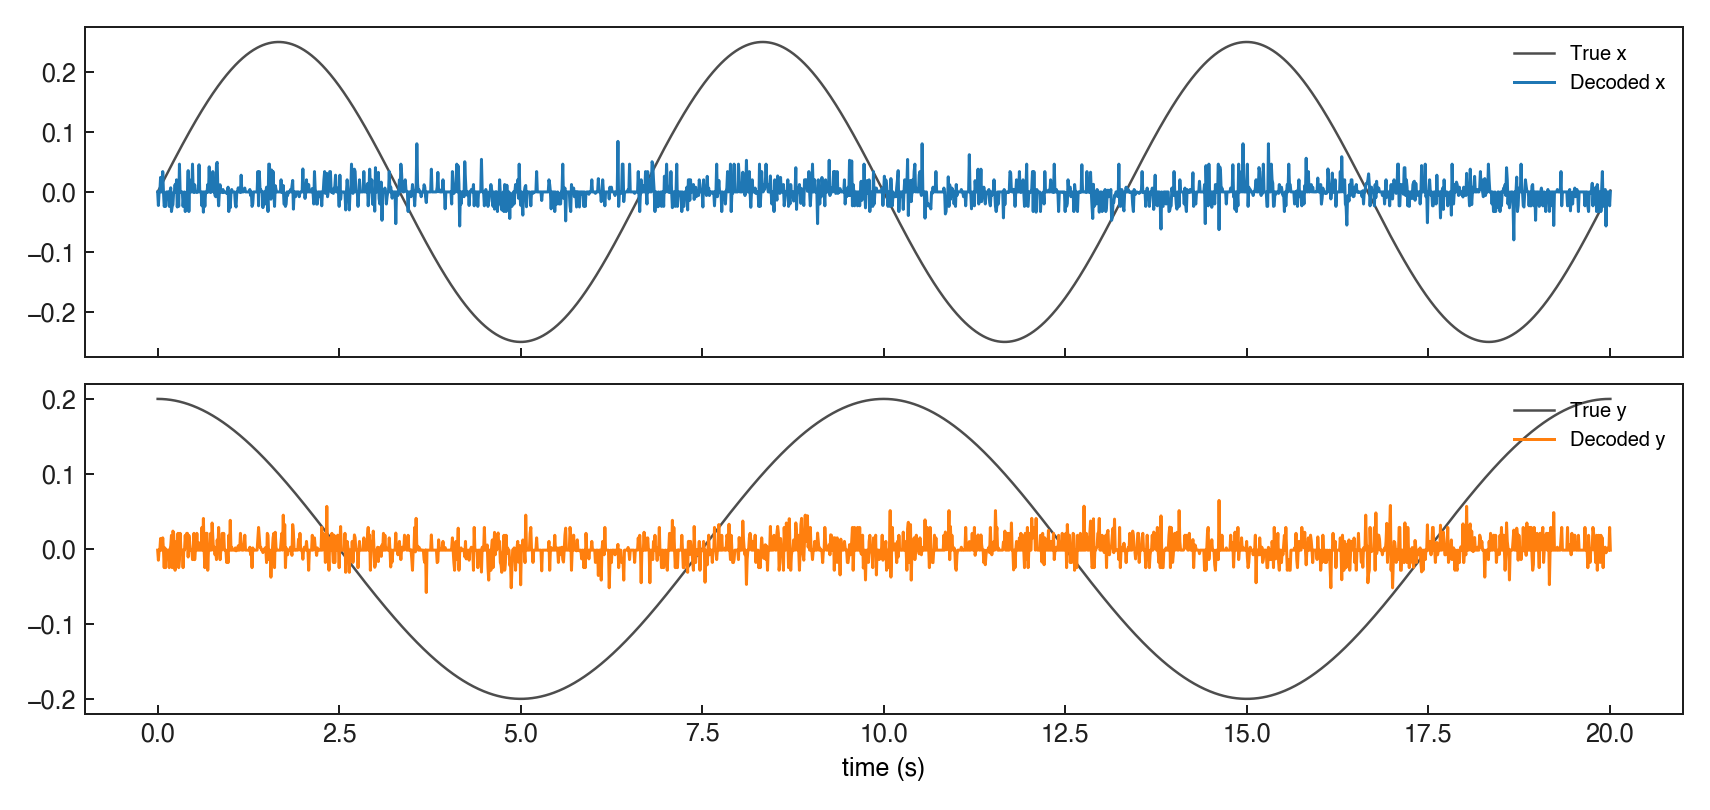

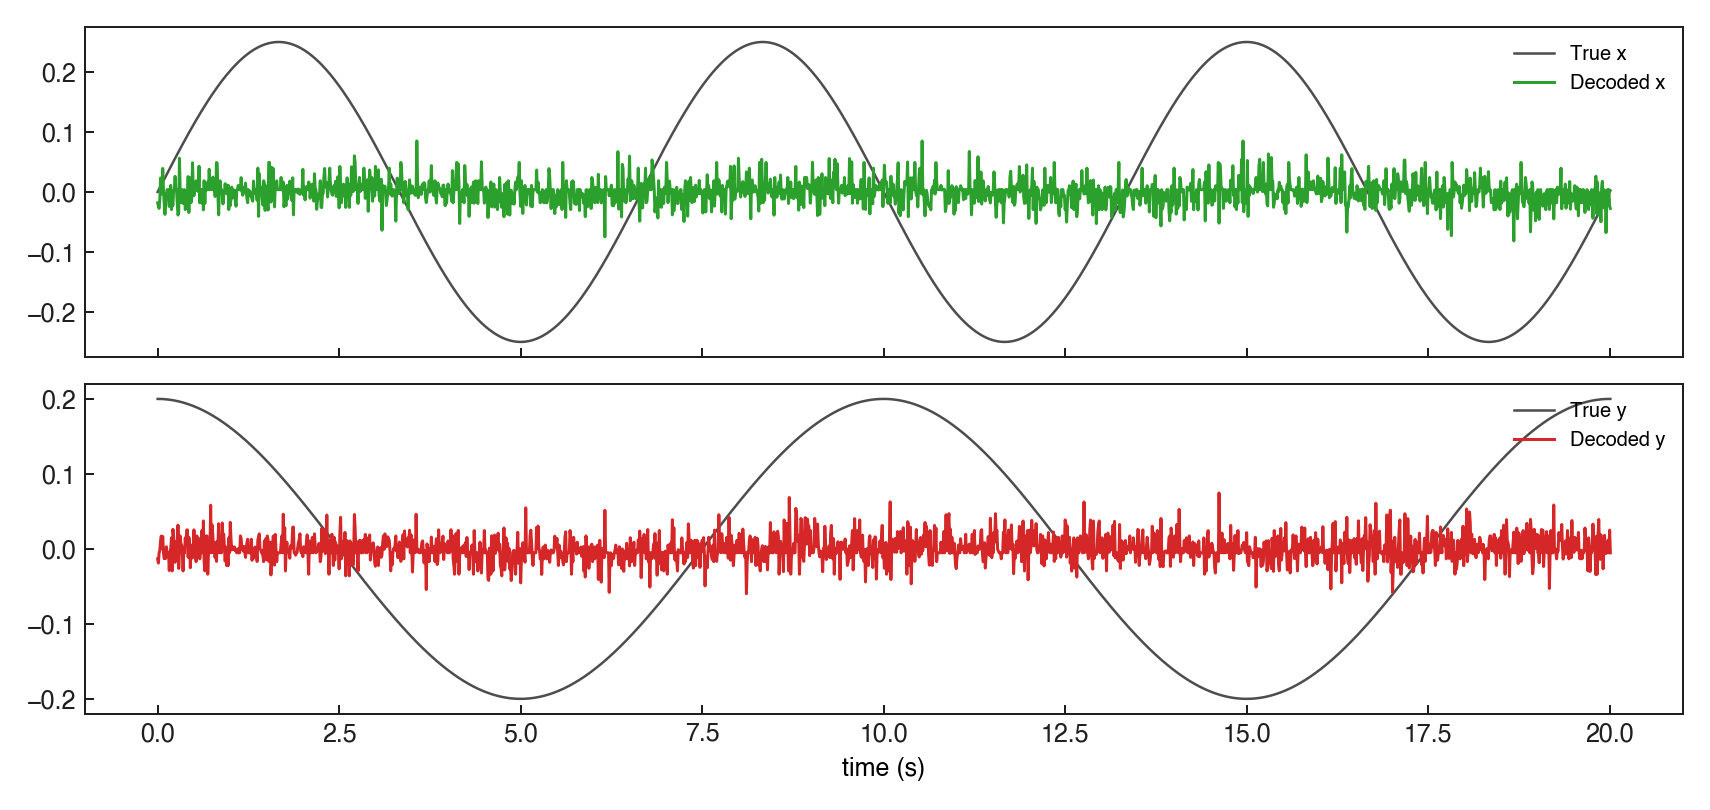

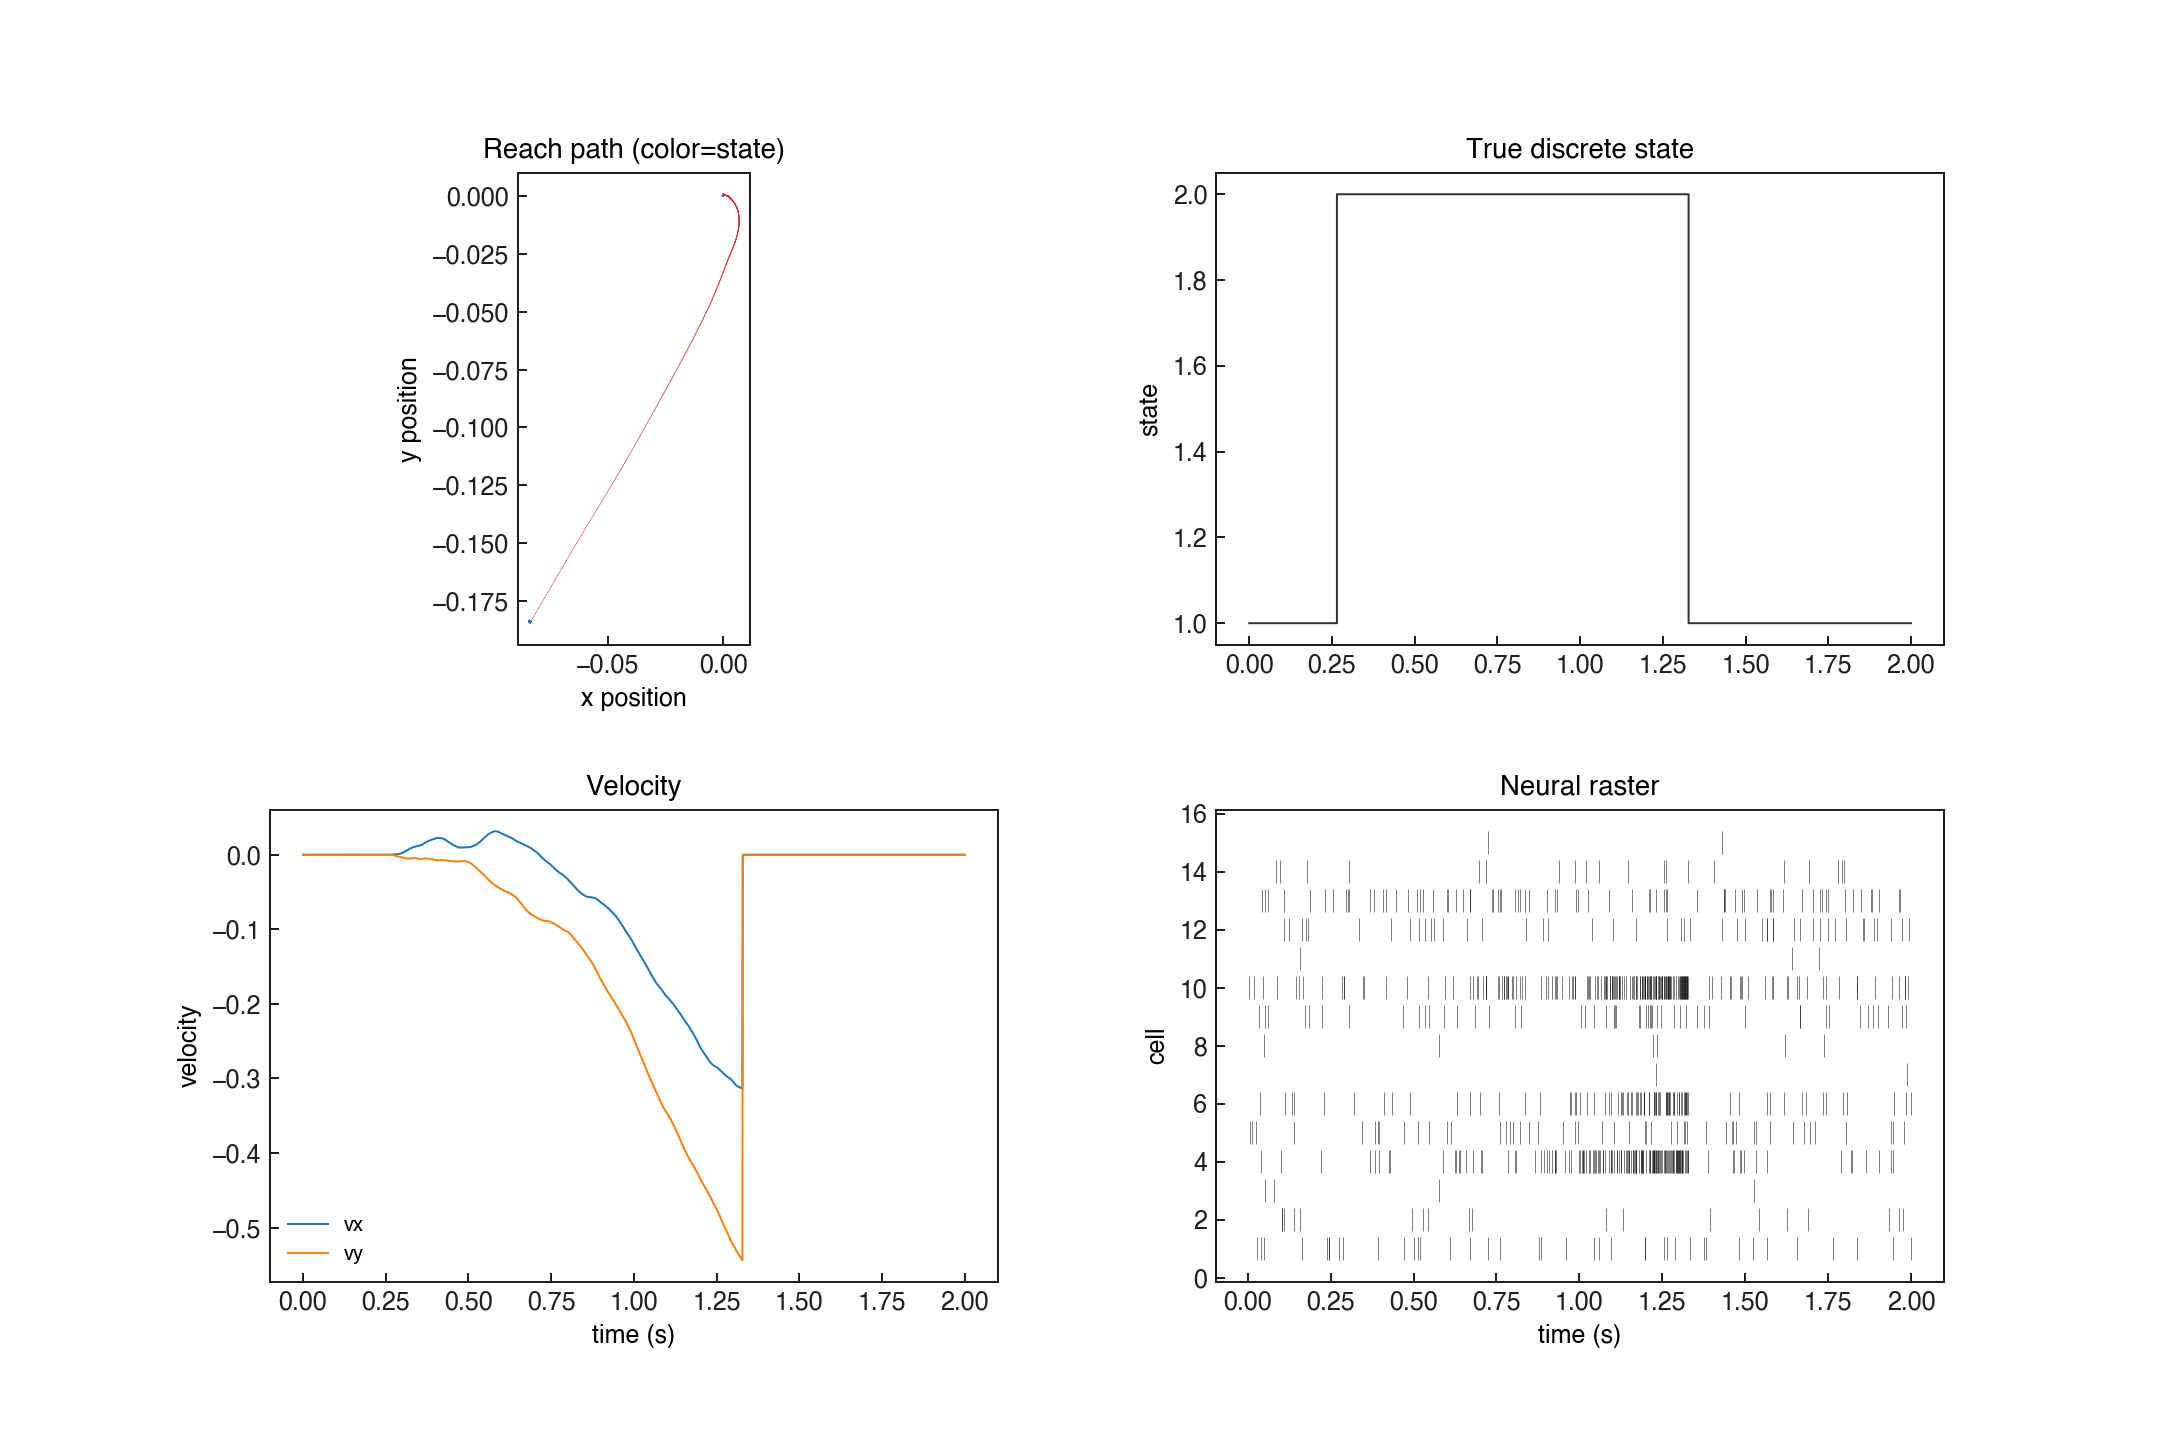

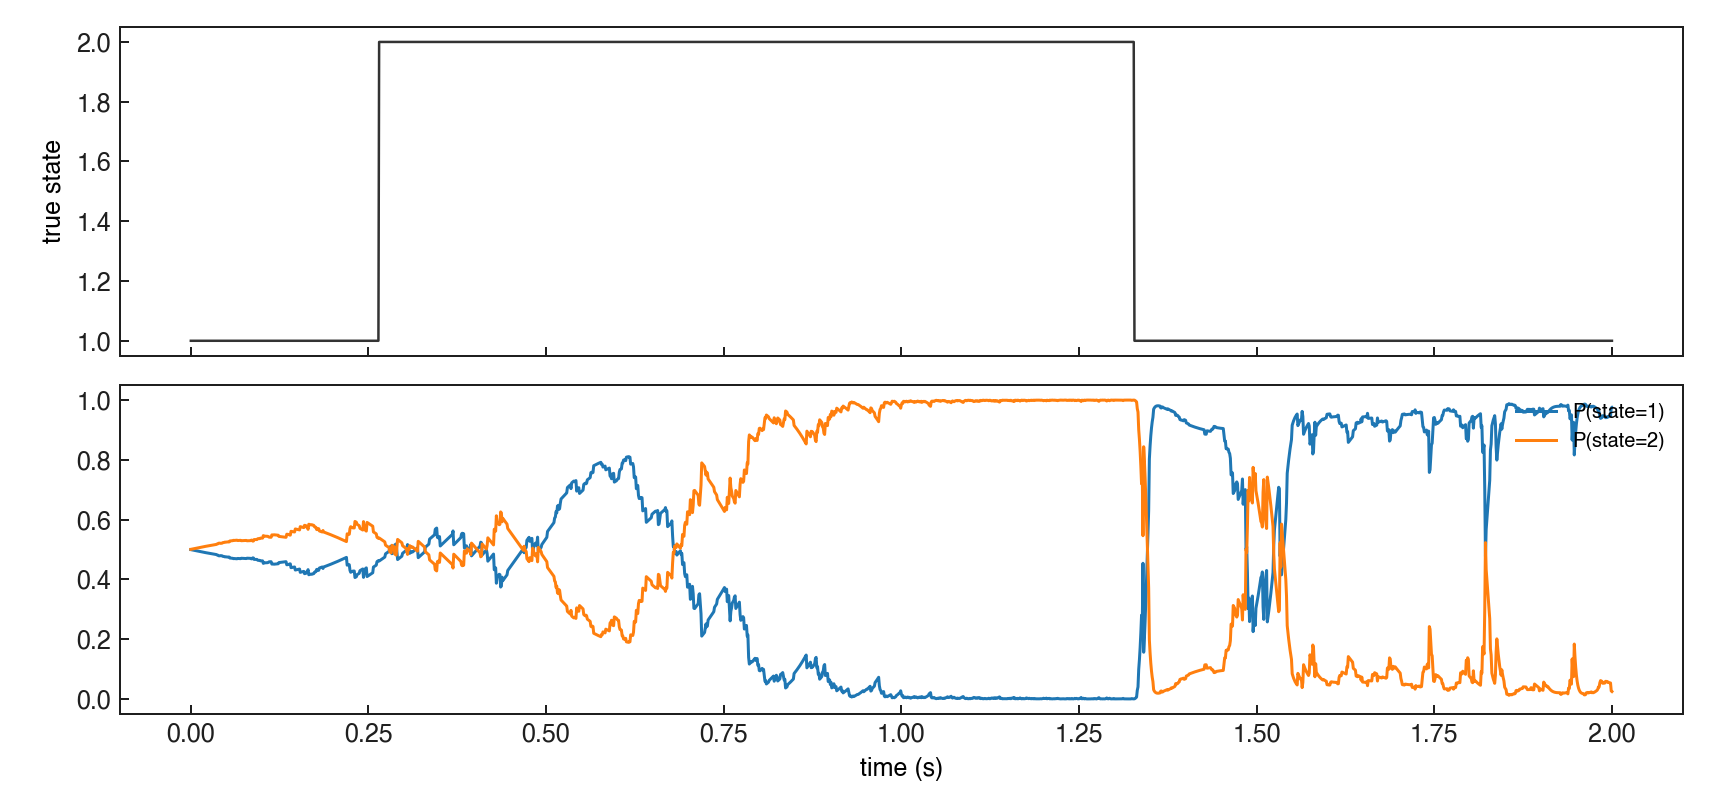

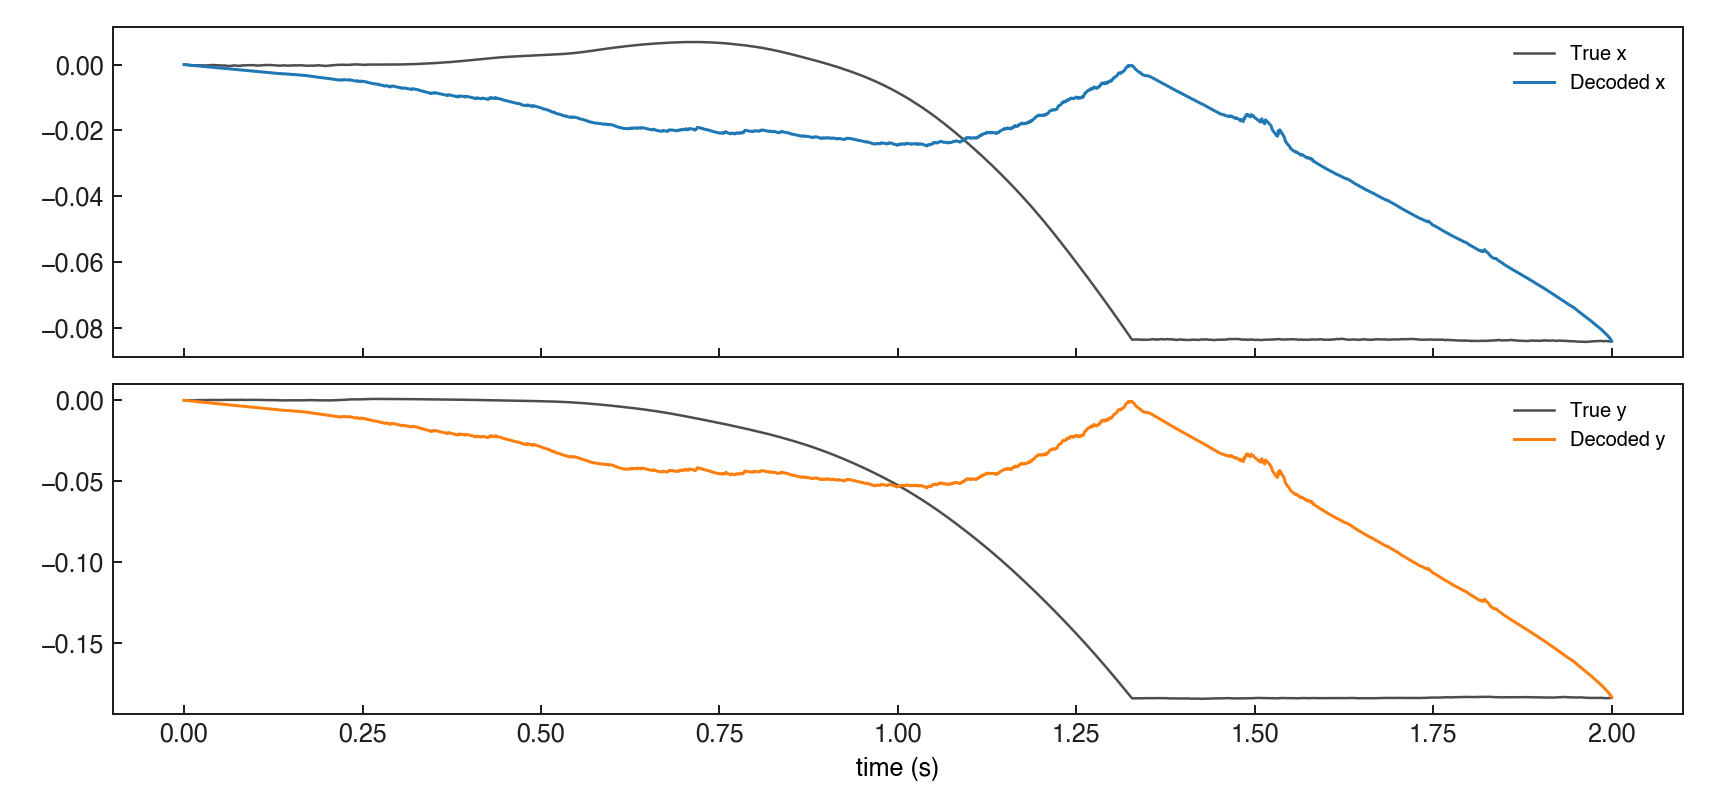

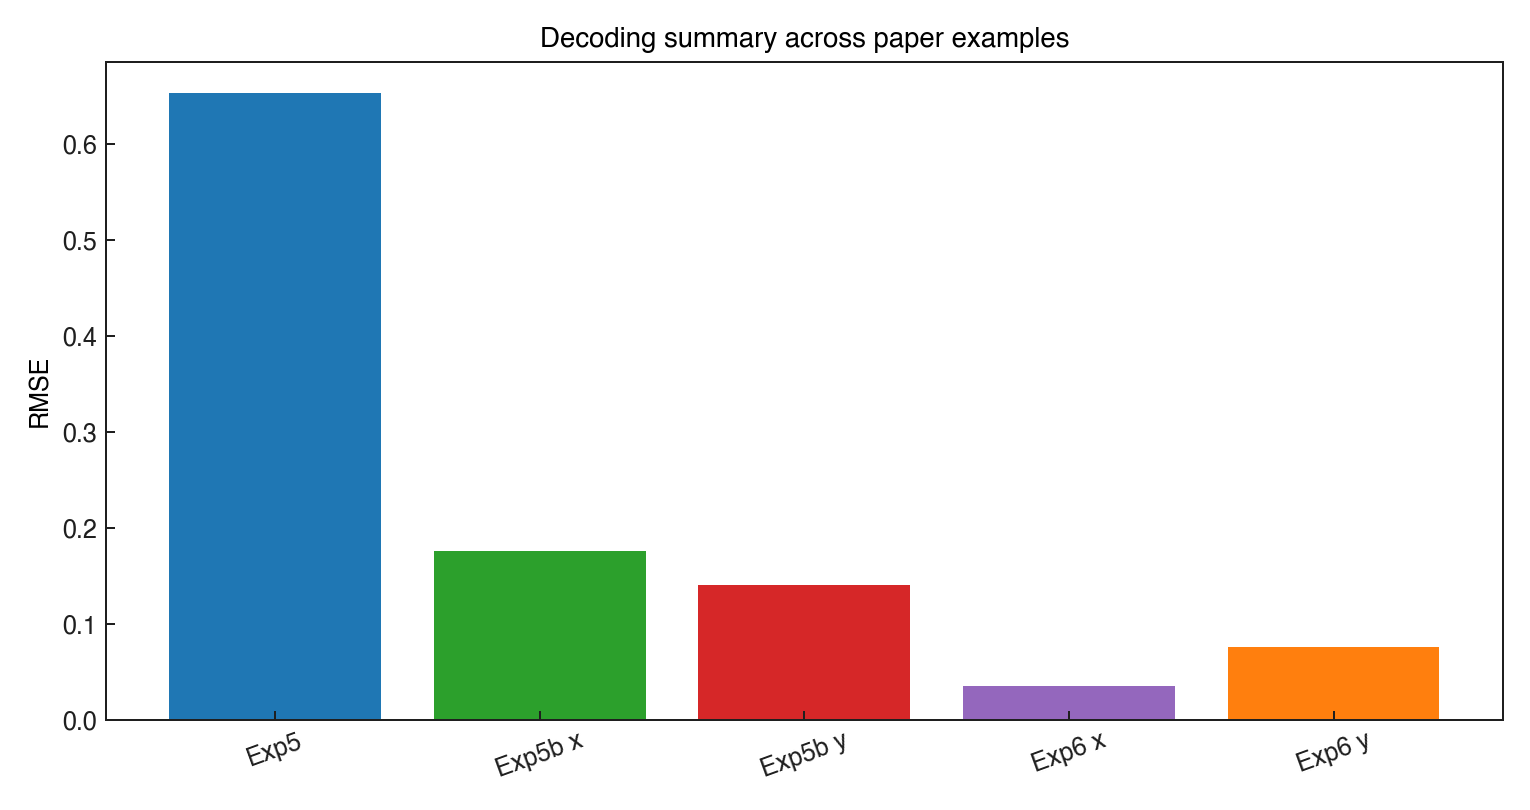

In [1]:
# nSTAT-python notebook example: nSTATPaperExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_data import notebook_example_data_dir
from nstat.notebook_figures import FigureTracker
from nstat.paper_examples_full import (
    run_experiment1,
    run_experiment2,
    run_experiment3,
    run_experiment3b,
    run_experiment4,
    run_experiment5,
    run_experiment5b,
    run_experiment6,
)

DATA_DIR = notebook_example_data_dir(allow_synthetic=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="nSTATPaperExamples", output_root=OUTPUT_ROOT, expected_count=29)

def _fig(label: str, *, figsize=(8.5, 4.5)):
    fig = __tracker.new_figure(label)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig

plt.close("all")
exp1_summary, exp1 = run_experiment1(DATA_DIR, return_payload=True)
exp2_summary, exp2 = run_experiment2(DATA_DIR, return_payload=True)
exp3_summary, exp3 = run_experiment3(return_payload=True)
exp3b_summary, exp3b = run_experiment3b(DATA_DIR, return_payload=True)
exp4_summary, exp4 = run_experiment4(DATA_DIR, return_payload=True)
exp5_summary, exp5 = run_experiment5(return_payload=True)
exp5b_summary, exp5b = run_experiment5b(return_payload=True)
exp6_summary, exp6 = run_experiment6(REPO_ROOT, return_payload=True)
print({"dataset_root": str(DATA_DIR), "paper_examples_loaded": 8})

# Experiment 1

MINIATURE EXCITATORY POST-SYNAPTIC CURRENTS (mEPSCs) Data from Marnie Phillips  marnie.a.phillips@gmail.com This analysis is based on a partial version of the dataset used in

Phillips MA, Lewis LD, Gong J, Constantine-Paton M, Brown EN. 2011 *Model-based statistical analysis of miniature synaptic transmission.* J Neurophys (under consideration)

**Date**: 03/01/2011


In [2]:
# SECTION 1: Experiment 1
print(exp1_summary)

{'const_condition_spikes': 573.0, 'const_model_aic': 3878.21450302445, 'const_model_bic': 3884.9477748694585, 'constant_acf_ci': 0.08188017465629394, 'decreasing_condition_spikes': 1870.0, 'piecewise_model_aic': 17581.121678089126, 'piecewise_model_bic': 17609.2027486881, 'piecewise_history_model_aic': 17585.640410038308, 'piecewise_history_model_bic': 17707.32504930054, 'dt_seconds': 0.01}


# Constant Magnesium Concentration - Constant rate poisson

Under a constant Magnesium concentration, it is seen that the mEPSCs behave as a homogeneous poisson process (constant arrival rate).


In [3]:
# SECTION 2: Constant Magnesium Concentration - Constant rate poisson
fig = _fig("experiment1 constant rate", figsize=(9.0, 4.0))
ax = fig.subplots(1, 1)
ax.plot(exp1["constant_time_s"], exp1["constant_rate_hz"], color="tab:blue", linewidth=1.4)
ax.set_xlabel("time (s)")
ax.set_ylabel("rate (Hz)")
ax.set_title("Constant Mg condition: homogeneous Poisson fit")

Text(0.5, 1.0, 'Constant Mg condition: homogeneous Poisson fit')

# Varying Magnesium Concentration - Piecewise Constant rate poisson

When the magnesium concentration of the bath decreased (i.e. magnesium is removed), the rate of mEPSCs begin to increase in frequency. This can be modeled in a many different ways (using the change in Magnesium directly as a model covariate, etc.) Here we approximate the rate as being constant during certain portions of the experiment. These segments can in principle be estimated (using heirarchical Bayesian methods), but here we select them via visual inspection. We compare three models: a constant rate model (from above), a piecewise constant rate model, and a piecewise constant rate model with history.


In [4]:
# SECTION 3: Varying Magnesium Concentration - Piecewise Constant rate poisson
print({"decreasing_condition_spikes": exp1_summary["decreasing_condition_spikes"], "piecewise_model_aic": round(float(exp1_summary["piecewise_model_aic"]), 3)})

{'decreasing_condition_spikes': 1870.0, 'piecewise_model_aic': 17581.122}


# Data Visualization

Visual inspection of the spike train is used to pick three regions where the firing rate appears to be different. Here we do not estimate where these transitions happen but pick times in an ad-hoc manner.


In [5]:
# SECTION 4: Data Visualization
fig = _fig("experiment1 washout raster and rates", figsize=(10.0, 5.5))
axs = fig.subplots(2, 1, sharex=True)
spike_times = np.asarray(exp1["washout_spike_times_s"], dtype=float)
axs[0].vlines(spike_times, 0.0, 1.0, color="k", linewidth=0.3)
axs[0].set_ylim(0.0, 1.0)
axs[0].set_ylabel("spikes")
axs[0].set_title("Decreasing Mg condition raster")
axs[1].plot(exp1["washout_time_s"], exp1["washout_observed_rate_hz"], color="0.3", linewidth=1.0, label="Observed")
axs[1].plot(exp1["washout_time_s"], exp1["washout_piecewise_rate_hz"], color="tab:green", linewidth=1.3, label="Piecewise")
axs[1].plot(exp1["washout_time_s"], exp1["washout_piecewise_history_rate_hz"], color="tab:red", linewidth=1.3, label="Piecewise+Hist")
for edge in exp1["washout_segment_edges_s"][1:-1]:
    axs[1].axvline(edge, color="tab:red", linestyle="--", linewidth=0.9)
axs[1].set_xlabel("time (s)")
axs[1].set_ylabel("rate (Hz)")
axs[1].legend(loc="upper left", frameon=False, fontsize=8)

In [6]:
# SECTION 5: Define Covariates for the analysis
fig = _fig("experiment1 constant ks", figsize=(6.0, 5.0))
ax = fig.subplots(1, 1)
ax.plot(exp1["constant_ks_ideal"], exp1["constant_ks_empirical"], color="tab:blue", linewidth=1.4)
ax.plot([0.0, 1.0], [0.0, 1.0], color="0.25", linestyle="--", linewidth=1.0)
ax.fill_between(exp1["constant_ks_ideal"], np.clip(exp1["constant_ks_ideal"] - exp1["constant_ks_ci"], 0.0, 1.0), np.clip(exp1["constant_ks_ideal"] + exp1["constant_ks_ci"], 0.0, 1.0), color="0.85")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("theoretical CDF")
ax.set_ylabel("empirical CDF")
ax.set_title("Constant-condition KS plot")

Text(0.5, 1.0, 'Constant-condition KS plot')

In [7]:
# SECTION 6: Define how we want to analyze the data
fig = _fig("experiment1 constant acf", figsize=(7.0, 4.0))
ax = fig.subplots(1, 1)
ax.vlines(exp1["constant_acf_lags_s"], 0.0, exp1["constant_acf_values"], color="tab:purple", linewidth=1.0)
ax.axhline(exp1_summary["constant_acf_ci"], color="tab:red", linewidth=1.0)
ax.axhline(-exp1_summary["constant_acf_ci"], color="tab:red", linewidth=1.0)
ax.set_xlabel("lag")
ax.set_ylabel("autocorrelation")
ax.set_title("Sequential correlation under constant Mg")

Text(0.5, 1.0, 'Sequential correlation under constant Mg')

# Perform Analysis

We see that the piece-wise constant rate model (without history) outperforms the constant baseline model in terms of AIC, BIC, and KS-statistic.


In [8]:
# SECTION 7: Perform Analysis
fig = _fig("experiment1 model summary", figsize=(7.5, 4.0))
ax = fig.subplots(1, 1)
names = ["Const", "Piecewise", "Piecewise+Hist"]
aics = [exp1_summary["const_model_aic"], exp1_summary["piecewise_model_aic"], exp1_summary["piecewise_history_model_aic"]]
ax.bar(np.arange(3), aics, color=["0.6", "tab:green", "tab:red"])
ax.set_xticks(np.arange(3), names)
ax.set_ylabel("AIC")
ax.set_title("Experiment 1 model comparison")

Text(0.5, 1.0, 'Experiment 1 model comparison')

# Experiment 2

EXPLICIT STIMULUS EXAMPLE - WHISKER STIMULATION/THALAMIC NEURON In the worksheet with analyze the stimulus effect and history effect on the firing of a thalamic neuron under a known stimulus consisting of whisker stimulation. Data from Demba Ba (demba@mit.edu)


In [9]:
# SECTION 8: Experiment 2
print(exp2_summary)

{'n_samples': 51000.0, 'model1_aic': 9597.1177937183, 'model2_aic': 1615663214437.8765, 'model3_aic': 1618939900919.947, 'model1_bic': 9605.957374630007, 'model2_bic': 1615663214464.3953, 'model3_bic': 1618939900990.6636, 'peak_lag_seconds': 0.11900000000000001}


# Load the data

clear all;

Fit a constant baseline and Find Stimulus Lag We fit a constant rate (Poisson) model to the data and use the look at the cross-covariance function of between the stimulus and the fit residual to determine the appropriate lag for the stimulus.


In [10]:
# SECTION 9: Load the data
fig = _fig("experiment2 stimulus and spikes", figsize=(10.0, 5.5))
axs = fig.subplots(2, 1, sharex=True)
spike_times = np.asarray(exp2["time_s"], dtype=float)[np.asarray(exp2["spike_indicator"], dtype=float) > 0.5]
axs[0].vlines(spike_times, 0.0, 1.0, color="k", linewidth=0.35)
axs[0].set_ylim(0.0, 1.0)
axs[0].set_ylabel("spikes")
axs[1].plot(exp2["time_s"], exp2["stimulus"], color="tab:blue", linewidth=1.2)
axs[1].set_ylabel("stimulus")
axs[1].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

In [11]:
fig = _fig("experiment2 xcorr", figsize=(7.0, 4.0))
ax = fig.subplots(1, 1)
ax.plot(1000.0 * np.asarray(exp2["xcorr_lags_s"], dtype=float), exp2["xcorr_values"], color="tab:purple", linewidth=1.3)
ax.set_xlabel("lag (ms)")
ax.set_ylabel("cross-covariance")
ax.set_title("Stimulus lag search")

Text(0.5, 1.0, 'Stimulus lag search')

# Compare constant rate model with model including stimulus effect

Addition of the stimulus improves the fits in terms of the KS plot and the making the rescaled ISIs less correlated. The Point Process Residula also looks more "white"


In [12]:
# SECTION 10: Compare constant rate model with model including stimulus effect
fig = _fig("experiment2 aic bic", figsize=(8.5, 4.0))
axs = fig.subplots(1, 2)
model_names = ["Baseline", "Stim", "Stim+Hist"]
axs[0].bar(np.arange(3), [exp2_summary["model1_aic"], exp2_summary["model2_aic"], exp2_summary["model3_aic"]], color=["0.65", "tab:blue", "tab:green"])
axs[0].set_xticks(np.arange(3), model_names, rotation=15)
axs[0].set_title("AIC")
axs[1].bar(np.arange(3), [exp2_summary["model1_bic"], exp2_summary["model2_bic"], exp2_summary["model3_bic"]], color=["0.65", "tab:blue", "tab:green"])
axs[1].set_xticks(np.arange(3), model_names, rotation=15)
axs[1].set_title("BIC")

Text(0.5, 1.0, 'BIC')

In [13]:
fig = _fig("experiment2 ks compare", figsize=(6.5, 5.0))
ax = fig.subplots(1, 1)
ideal = np.asarray(exp2["ks_ideal"], dtype=float)
ax.plot(ideal, ideal, color="0.25", linestyle="--", linewidth=1.0)
ax.plot(ideal, exp2["ks_const_empirical"], color="tab:blue", linewidth=1.2, label="Baseline")
ax.plot(ideal, exp2["ks_stim_empirical"], color="tab:orange", linewidth=1.2, label="Stim")
ax.plot(ideal, exp2["ks_hist_empirical"], color="tab:green", linewidth=1.2, label="Stim+Hist")
ax.fill_between(ideal, np.clip(ideal - exp2["ks_ci"], 0.0, 1.0), np.clip(ideal + exp2["ks_ci"], 0.0, 1.0), color="0.88")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(loc="lower right", frameon=False, fontsize=8)
ax.set_title("Experiment 2 KS diagnostics")

Text(0.5, 1.0, 'Experiment 2 KS diagnostics')

# History Effect

Determine the best history effect model using AIC, BIC, and KS statistic


In [14]:
# SECTION 11: History Effect
fig = _fig("experiment2 history scan", figsize=(8.5, 7.0))
axs = fig.subplots(3, 1, sharex=True)
windows = np.asarray(exp2["history_windows"], dtype=float)
axs[0].plot(windows, exp2["ks_stats"], marker="o", color="tab:purple", linewidth=1.2)
axs[0].set_ylabel("KS")
axs[1].plot(windows, exp2["delta_aic"], marker="o", color="tab:green", linewidth=1.2)
axs[1].set_ylabel("Delta AIC")
axs[2].plot(windows, exp2["delta_bic"], marker="o", color="tab:brown", linewidth=1.2)
axs[2].set_ylabel("Delta BIC")
axs[2].set_xlabel("history windows")

Text(0.5, 0, 'history windows')

In [15]:
fig = _fig("experiment2 coefficients", figsize=(9.0, 4.5))
ax = fig.subplots(1, 1)
xpos = np.arange(len(exp2["coef_names"]))
coef_values = np.asarray(exp2["coef_values"], dtype=float)
lower = np.asarray(exp2["coef_lower"], dtype=float)
upper = np.asarray(exp2["coef_upper"], dtype=float)
ax.errorbar(xpos, coef_values, yerr=np.vstack([coef_values - lower, upper - coef_values]), fmt="o", color="tab:blue", capsize=3)
ax.set_xticks(xpos, exp2["coef_names"], rotation=30)
ax.set_ylabel("coefficient value")
ax.set_title("Experiment 2 coefficient intervals")

Text(0.5, 1.0, 'Experiment 2 coefficient intervals')

In [16]:
# SECTION 12: Example 3 - PSTH Data
print(exp3_summary)

{'num_trials': 20.0, 'psth_peak_hz': 124.99999999999994, 'psth_mean_hz': 53.749999999999986, 'total_spikes': 1075.0}


In [17]:
fig = _fig("experiment3 true rate", figsize=(9.0, 4.0))
ax = fig.subplots(1, 1)
ax.plot(exp3["time_s"], exp3["true_rate_hz"], color="tab:blue", linewidth=1.3)
ax.set_xlabel("time (s)")
ax.set_ylabel("rate (Hz)")
ax.set_title("Experiment 3 true conditional intensity")

Text(0.5, 1.0, 'Experiment 3 true conditional intensity')

In [18]:
# SECTION 13: Estimate the PSTH with 50ms windows
fig = _fig("experiment3 psth", figsize=(9.0, 5.0))
axs = fig.subplots(2, 1, sharex=True)
for row, spikes in enumerate(exp3["raster_spike_times"][:10], start=1):
    axs[0].vlines(spikes, row - 0.4, row + 0.4, color="k", linewidth=0.3)
axs[0].set_ylabel("trial")
axs[1].plot(exp3["psth_bin_centers_s"], exp3["psth_rate_hz"], color="tab:red", linewidth=1.4)
axs[1].set_ylabel("PSTH (Hz)")
axs[1].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

# Example 3b - SSGLM Example

Example of estimating with-in and across trial dynamics Methods from: G. Czanner, U. T. Eden, S. Wirth, M. Yanike, W. A. Suzuki, and E. N. Brown, "Analysis of between-trial and within-trial neural spiking dynamics.," Journal of neurophysiology, vol. 99, no. 5, pp. 2672?2693, May. 2008.


In [19]:
# SECTION 14: Example 3b - SSGLM Example
print(exp3b_summary)

{'num_trials': 25.0, 'num_time_bins': 50.0, 'state_rmse': 118.29190338935122, 'ci_coverage': 1.0, 'mean_qhat': 0.01646313440905654, 'mean_gammahat': -1.8798710833855103, 'log_likelihood': -0.19416505639708248}


In [20]:
# SECTION 15: Summarize Simulated Data
fig = _fig("experiment3b state estimates", figsize=(10.0, 5.0))
axs = fig.subplots(2, 1, sharex=True)
axs[0].imshow(exp3b["stimulus"], aspect="auto", cmap="viridis")
axs[0].set_title("True stimulus")
axs[1].imshow(exp3b["xk"], aspect="auto", cmap="viridis")
axs[1].set_title("Decoded state")
axs[1].set_xlabel("time bin")

Text(0.5, 0, 'time bin')

In [21]:
# SECTION 16: Estimation of the Stimulus Response
fig = _fig("experiment3b ci width", figsize=(8.5, 4.5))
axs = fig.subplots(1, 2)
axs[0].plot(np.mean(exp3b["ci_width"], axis=0), color="tab:orange", linewidth=1.3)
axs[0].set_title("Mean CI width over time")
axs[1].plot(np.mean(exp3b["qhat_all"], axis=0), marker="o", color="tab:blue", linewidth=1.2)
axs[1].set_title("Mean Qhat across models")

Text(0.5, 1.0, 'Mean Qhat across models')

In [22]:
# SECTION 17: Run the SSGLM Filter
fig = _fig("experiment3b gamma", figsize=(8.5, 4.5))
axs = fig.subplots(1, 2)
axs[0].bar(np.arange(len(exp3b["gammahat"])), exp3b["gammahat"], color="tab:green")
axs[0].set_title("gammahat")
axs[1].plot(np.asarray(exp3b["gammahat_all"], dtype=float), marker="o", color="tab:red", linewidth=1.2)
axs[1].set_title("gammahatAll")

Text(0.5, 1.0, 'gammahatAll')

# Example 4 - HIPPOCAMPAL PLACE CELL - RECEPTIVE FIELD ESTIMATION

Estimation of receptive fields of neurons is a very common data analysis problem in neuroscience. Here we use the nSTAT software to perform an estimation of the receptive fields of hippocampal place cells using a bivariate Gaussian model and Zernike polynomials. The number of zernike polynomials is based on "An Analysis of Hippocampal Spatio-Temporal Representations Using a Bayesian Algorithm for Neural Spike Train Decoding" Barbieri et. al 2005. The data used herein in was provided by Dr. Ricardo Barbieri on 2/28/2011.

**Author**: Iahn Cajigas

**Date**: 3/1/2011


In [23]:
# SECTION 18: Example 4 - HIPPOCAMPAL PLACE CELL - RECEPTIVE FIELD ESTIMATION
print(exp4_summary)

{'num_cells_fit': 8.0, 'mean_delta_aic_gaussian_minus_zernike': 87.65071800242686, 'mean_delta_bic_gaussian_minus_zernike': 44.35785401057149}


# Example Data

The x and y coordinates of a freely foraging rat in a circular environment (70cm in diameter and 30cm high walls) and a fixed visual cue. The x and y coordinates at the time when a spike was observed are marked in red. The position coordinates have been normalized to be between -1 and 1 to allow to simplify the analysis.


In [24]:
# SECTION 19: Example Data
fig = _fig("experiment4 animal1 delta aic", figsize=(7.5, 4.0))
ax = fig.subplots(1, 1)
ax.bar(np.arange(len(exp4["animal1"]["selected_indices"])), exp4["animal1"]["delta_aic"], color="tab:blue")
ax.set_xticks(np.arange(len(exp4["animal1"]["selected_indices"])), [str(int(v) + 1) for v in exp4["animal1"]["selected_indices"]])
ax.set_ylabel("Gaussian - Zernike AIC")
ax.set_title("Animal 1 place-cell comparison")

Text(0.5, 1.0, 'Animal 1 place-cell comparison')

In [25]:
# SECTION 20: Analyze All Cells
fig = _fig("experiment4 animal2 delta bic", figsize=(7.5, 4.0))
ax = fig.subplots(1, 1)
ax.bar(np.arange(len(exp4["animal2"]["selected_indices"])), exp4["animal2"]["delta_bic"], color="tab:green")
ax.set_xticks(np.arange(len(exp4["animal2"]["selected_indices"])), [str(int(v) + 1) for v in exp4["animal2"]["selected_indices"]])
ax.set_ylabel("Gaussian - Zernike BIC")
ax.set_title("Animal 2 place-cell comparison")

Text(0.5, 1.0, 'Animal 2 place-cell comparison')

# View Summary Statistics

Note the Zernike Polynomials yield better fits in terms of decreased KS Statistics (less deviation from the 45 degree line), reduced AIC and reduced BIC across the majority of cells and for both animals


In [26]:
# SECTION 21: View Summary Statistics
fig = _fig("experiment4 gaussian mesh", figsize=(9.0, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(exp4["mesh"]["grid_x"], exp4["mesh"]["grid_y"], exp4["mesh"]["gaussian_field"], cmap="Blues", linewidth=0.0, antialiased=True)
ax.set_title("Gaussian place-field estimate")

Text(0.5, 0.92, 'Gaussian place-field estimate')

In [27]:
# SECTION 22: Visualize the results
fig = _fig("experiment4 zernike mesh", figsize=(9.0, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(exp4["mesh"]["grid_x"], exp4["mesh"]["grid_y"], exp4["mesh"]["zernike_field"], cmap="Greens", linewidth=0.0, antialiased=True)
ax.set_title("Zernike place-field estimate")

Text(0.5, 0.92, 'Zernike place-field estimate')

In [28]:
print(exp5_summary)

{'num_cells': 20.0, 'decode_rmse': 0.6531227068287989}


# Example 5 - STIMULUS DECODING

In this example we show how to decode a univariate and a bivariate stimulus based on a point process observations using nSTAT. Even though due to the simulated nature of the data, we know the exact condition intensity function, we estimate the parameters before moving on to the decoding stage.


In [29]:
# SECTION 23: Example 5 - STIMULUS DECODING
fig = _fig("experiment5 cif setup", figsize=(10.0, 8.0))
axs = fig.subplots(3, 1, sharex=True)
# Panel 1: driving stimulus
axs[0].plot(exp5["time_s"], exp5["stimulus"], color="tab:blue", linewidth=1.2)
axs[0].set_ylabel("stimulus")
axs[0].set_title("Experiment 5: CIF setup")
# Panel 2: conditional intensity for each cell
for j in range(exp5["cif_rates"].shape[1]):
    axs[1].plot(exp5["time_s"], exp5["cif_rates"][:, j], linewidth=0.6, alpha=0.7)
axs[1].set_ylabel("CIF rate (Hz)")
# Panel 3: spike raster
for j in range(exp5["spikes"].shape[1]):
    t_spk = exp5["time_s"][exp5["spikes"][:, j] > 0.5]
    axs[2].vlines(t_spk, j + 0.6, j + 1.4, color="k", linewidth=0.3)
axs[2].set_ylabel("cell")
axs[2].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

In [30]:
# SECTION 24: Generate the conditional Intensity Function
fig = _fig("experiment5 stimulus decode", figsize=(9.0, 4.5))
ax = fig.subplots(1, 1)
ax.plot(exp5["time_s"], exp5["stimulus"], color="0.3", linewidth=1.0, label="True")
ax.plot(exp5["time_s"], exp5["decoded"], color="tab:blue", linewidth=1.4, label="Decoded")
ax.fill_between(exp5["time_s"], exp5["ci_low"], exp5["ci_high"], color="0.85")
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.set_xlabel("time (s)")
ax.set_title("Experiment 5 adaptive decoding")

Text(0.5, 1.0, 'Experiment 5 adaptive decoding')

In [31]:
print(exp5b_summary)

{'num_cells': 30.0, 'num_samples': 2002.0, 'decode_rmse_x': 0.17559231283627283, 'decode_rmse_y': 0.14050174855856312}


# Example 5b - Arm reaching to target Simulation

See L. Srinivasan, U. T. Eden, A. S. Willsky, and E. N. Brown, "A state-space analysis for reconstruction of goal-directed movements using neural signals.," Neural computation, vol. 18, no. 10, pp. 2465?2494, Oct. 2006.


In [32]:
# SECTION 25: Example 5b - Arm reaching to target Simulation
fig = _fig("experiment5b reach setup", figsize=(12.0, 8.0))
axs = fig.subplots(2, 2, gridspec_kw={"hspace": 0.35, "wspace": 0.3})
# (0,0) 2-D reach path
axs[0, 0].plot(exp5b["x_true"], exp5b["y_true"], color="0.3", linewidth=0.8)
axs[0, 0].set_xlabel("x position")
axs[0, 0].set_ylabel("y position")
axs[0, 0].set_title("Reach trajectory")
axs[0, 0].set_aspect("equal")
# (0,1) position profiles
axs[0, 1].plot(exp5b["time_s"], exp5b["x_true"], color="tab:blue", linewidth=1.0, label="x")
axs[0, 1].plot(exp5b["time_s"], exp5b["y_true"], color="tab:orange", linewidth=1.0, label="y")
axs[0, 1].set_ylabel("position")
axs[0, 1].legend(frameon=False, fontsize=8)
axs[0, 1].set_title("Position")
# (1,0) velocity profiles
axs[1, 0].plot(exp5b["time_s"], exp5b["vx_true"], color="tab:blue", linewidth=1.0, label="vx")
axs[1, 0].plot(exp5b["time_s"], exp5b["vy_true"], color="tab:orange", linewidth=1.0, label="vy")
axs[1, 0].set_ylabel("velocity")
axs[1, 0].set_xlabel("time (s)")
axs[1, 0].legend(frameon=False, fontsize=8)
axs[1, 0].set_title("Velocity")
# (1,1) spike raster
for j in range(min(exp5b["spikes"].shape[1], 15)):
    t_spk = exp5b["time_s"][exp5b["spikes"][:, j] > 0.5]
    axs[1, 1].vlines(t_spk, j + 0.6, j + 1.4, color="k", linewidth=0.2)
axs[1, 1].set_ylabel("cell")
axs[1, 1].set_xlabel("time (s)")
axs[1, 1].set_title("Neural raster")

Text(0.5, 1.0, 'Neural raster')

In [33]:
fig = _fig("experiment5b goal decode", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(exp5b["time_s"], exp5b["x_true"], color="0.3", linewidth=1.0, label="True x")
axs[0].plot(exp5b["time_s"], exp5b["dx_goal"], color="tab:blue", linewidth=1.2, label="Decoded x")
axs[0].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].plot(exp5b["time_s"], exp5b["y_true"], color="0.3", linewidth=1.0, label="True y")
axs[1].plot(exp5b["time_s"], exp5b["dy_goal"], color="tab:orange", linewidth=1.2, label="Decoded y")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")

/Users/iahncajigas/Library/CloudStorage/Dropbox/Claude/nSTAT-python/nstat/notebook_figures.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._active_fig.tight_layout()


Text(0.5, 0, 'time (s)')

In [34]:
fig = _fig("experiment5b free decode", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(exp5b["time_s"], exp5b["x_true"], color="0.3", linewidth=1.0, label="True x")
axs[0].plot(exp5b["time_s"], exp5b["dx_free"], color="tab:green", linewidth=1.2, label="Decoded x")
axs[0].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].plot(exp5b["time_s"], exp5b["y_true"], color="0.3", linewidth=1.0, label="True y")
axs[1].plot(exp5b["time_s"], exp5b["dy_free"], color="tab:red", linewidth=1.2, label="Decoded y")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

# Experiment 6 - Hybrid Point Process Filter Example

NOTE THIS EXAMPLE WAS NOT INCLUDED IN THE FINAL VERSION OF THE PAPER This example is based on an implementation of the Hybrid Point Process filter described in *General-purpose filter design for neural prosthetic devices* by Srinivasan L, Eden UT, Mitter SK, Brown EN in J Neurophysiol. 2007 Oct, 98(4):2456-75.


In [35]:
# SECTION 26: Experiment 6 - Hybrid Point Process Filter Example
print(exp6_summary)

{'num_samples': 3000.0, 'num_cells': 24.0, 'state_accuracy': 0.899, 'decode_rmse_x': 0.21622609499000853, 'decode_rmse_y': 0.17204447423928235}


# Problem Statement

Suppose that a process of interest can be modeled as consisting of several discrete states where the evolution of the system under each state can be modeled as a linear state space model. The observations of both the state and the continuous dynamics are not direct, but rather observed through how the continuous and discrete states affect the firing of a population of neurons. The goal of the hybrid filter is to estimate both the continuous dynamics and the underlying system state from only the neural population firing (point process observations).

To illustrate the use of this filter, we consider a reaching task. We assume two underlying system states s=1="Not Moving"=NM and s=2="Moving"=M. Under the "Not Moving" the position of the arm remain constant, whereas in the "Moving" state, the position and velocities evolved based on the arm acceleration that is modeled as a gaussian white noise process.

Under both the "Moving" and "Not Moving" states, the arm evolution state vector is

{\bf{x}} = {[x,y,{v_x},{v_y},{a_x},{a_y}]^T}


In [36]:
# SECTION 27: Problem Statement
fig = _fig("experiment6 hybrid setup", figsize=(12.0, 8.0))
axs = fig.subplots(2, 2, gridspec_kw={"hspace": 0.35, "wspace": 0.3})
# (0,0) 2-D reach path coloured by state
colors = np.where(exp6["state_true"] == 1.0, "tab:blue", "tab:red")
axs[0, 0].scatter(exp6["x_pos"], exp6["y_pos"], c=colors, s=0.15, linewidths=0)
axs[0, 0].set_xlabel("x position")
axs[0, 0].set_ylabel("y position")
axs[0, 0].set_title("Reach path (color=state)")
axs[0, 0].set_aspect("equal")
# (0,1) true discrete state
axs[0, 1].plot(exp6["time_s"], exp6["state_true"], color="0.2", linewidth=0.8, drawstyle="steps-post")
axs[0, 1].set_ylabel("state")
axs[0, 1].set_title("True discrete state")
# (1,0) velocity profiles
axs[1, 0].plot(exp6["time_s"], exp6["x_vel"], color="tab:blue", linewidth=0.8, label="vx")
axs[1, 0].plot(exp6["time_s"], exp6["y_vel"], color="tab:orange", linewidth=0.8, label="vy")
axs[1, 0].set_ylabel("velocity")
axs[1, 0].set_xlabel("time (s)")
axs[1, 0].legend(frameon=False, fontsize=8)
axs[1, 0].set_title("Velocity")
# (1,1) spike raster
for j in range(min(exp6["spikes"].shape[1], 15)):
    t_spk = exp6["time_s"][exp6["spikes"][:, j] > 0.5]
    axs[1, 1].vlines(t_spk, j + 0.6, j + 1.4, color="k", linewidth=0.2)
axs[1, 1].set_ylabel("cell")
axs[1, 1].set_xlabel("time (s)")
axs[1, 1].set_title("Neural raster")

Text(0.5, 1.0, 'Neural raster')

In [37]:
# SECTION 28: Generated Simulated Arm Reach
fig = _fig("experiment6 state probabilities", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(exp6["time_s"], exp6["state_true"], color="0.2", linewidth=1.0)
axs[0].set_ylabel("true state")
axs[1].plot(exp6["time_s"], exp6["state_prob_1"], color="tab:blue", linewidth=1.2, label="P(state=1)")
axs[1].plot(exp6["time_s"], exp6["state_prob_2"], color="tab:orange", linewidth=1.2, label="P(state=2)")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

# Simulate Neural Firing

We simulate a population of neurons that fire in response to the movement velocity (x and y coorinates)


In [38]:
# SECTION 29: Simulate Neural Firing
fig = _fig("experiment6 decoded positions", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(exp6["time_s"], exp6["x_pos"], color="0.3", linewidth=1.0, label="True x")
axs[0].plot(exp6["time_s"], exp6["decoded_x"], color="tab:blue", linewidth=1.2, label="Decoded x")
axs[0].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].plot(exp6["time_s"], exp6["y_pos"], color="0.3", linewidth=1.0, label="True y")
axs[1].plot(exp6["time_s"], exp6["decoded_y"], color="tab:orange", linewidth=1.2, label="Decoded y")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

In [39]:
fig = _fig("paper gallery summary", figsize=(8.5, 4.5))
ax = fig.subplots(1, 1)
rmses = [exp5_summary["decode_rmse"], exp5b_summary["decode_rmse_x"], exp5b_summary["decode_rmse_y"], exp6_summary["decode_rmse_x"], exp6_summary["decode_rmse_y"]]
labels = ["Exp5", "Exp5b x", "Exp5b y", "Exp6 x", "Exp6 y"]
ax.bar(np.arange(len(labels)), rmses, color=["tab:blue", "tab:green", "tab:red", "tab:purple", "tab:orange"])
ax.set_xticks(np.arange(len(labels)), labels, rotation=20)
ax.set_ylabel("RMSE")
ax.set_title("Decoding summary across paper examples")

Text(0.5, 1.0, 'Decoding summary across paper examples')

In [41]:
print(
    {
        "experiment1_piecewise_history_aic": round(float(exp1_summary["piecewise_history_model_aic"]), 3),
        "experiment2_peak_lag_ms": round(float(exp2_summary["peak_lag_seconds"]) * 1000.0, 1),
        "experiment4_mean_delta_aic": round(float(exp4_summary["mean_delta_aic_gaussian_minus_zernike"]), 3),
        "experiment6_state_accuracy": round(float(exp6_summary["state_accuracy"]), 3),
    }
)
__tracker.finalize()

{'experiment1_piecewise_history_aic': 17585.64, 'experiment2_peak_lag_ms': 119.0, 'experiment4_mean_delta_aic': 87.651, 'experiment6_state_accuracy': 0.899}
